# Temperature Analysis — Long-term & Acute Experiments (P3)
**STAT 628 Module 2: Cranberry Heat Stress**

This notebook contains the complete temperature analysis for both experiments:

- **Part A (Sections 0–13):** Long-term experiment — passive OTC warming, full season Jun–Sep 2024
- **Part B (Sections 14–18):** Acute experiment — 40°C heat pulses, 2-hour windows

**Input:** Raw 4-channel sensor CSVs, HOBO sensor CSVs, overview Excel  
**Output:** Cleaned data, summary tables, diagnostic plots for both experiments

---
# Part A: Long-term Experiment Temperature Analysis

Analyzes OTC vs Control canopy temperature across the full growing season (Jun 5 – Sep 24, 2024), Sets 7–14.

# Long-term Heat Experiment — Temperature Analysis

Analyzes OTC vs Control canopy temperature difference across the full growing season (2024-06-05 to 2024-09-24) to evaluate the passive warming effect of open-top chambers.

**Data source:** `data_longterm/4 Channel Sensors/` + `data_longterm/HOBO Sensors/`

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from scipy import stats

## 0. Path Configuration

Set `base_dir` to the local path of your `cranberry-data` folder.

In [6]:
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 200)

BASE_DIR = Path.cwd()
base_dir = BASE_DIR / "cranberry-data"

lt_dir          = base_dir / 'data_longterm'
lt_channel_dir  = lt_dir  / '4 Channel Sensors'
lt_hobo_dir     = lt_dir  / 'HOBO Sensors'
lt_yield_file   = lt_dir  / 'LTYielddata2024.csv'

mixed_dir       = base_dir / 'data_mixed'
overview_file   = mixed_dir / 'Listofdates_HeatStressTreatments2024.xlsx'
OVERVIEW_XLSX = overview_file

print('lt_channel_dir exists:', lt_channel_dir.exists())
print('lt_hobo_dir exists:',    lt_hobo_dir.exists())
print('overview_file exists:',  overview_file.exists())

lt_channel_dir exists: True
lt_hobo_dir exists: True
overview_file exists: True


## 1. 4-Channel Sensor Data — Load & Clean

Each set (7–14) has multiple download files with overlapping time ranges.
Processing strategy: merge all files within a set → deduplicate by timestamp (keep the latest downloaded version) → replace sensor error codes.

**Deduplication strategy:** Because later downloads most often, but not always, contained previously recorded observations, all files within each set are concatenated, sorted by `(datetime, source_file)`, and deduplicated keeping the last record per timestamp.

In [8]:
channel_files = pd.DataFrame({
    "file_name": [f.name for f in lt_channel_dir.glob("*.csv")]
})

channel_files["set"] = channel_files["file_name"].str.extract(r"Set(\d+)_LT")[0].astype(int)

channel_files["download_date"] = pd.to_datetime(
    channel_files["file_name"].str.extract(r"LT(\d{8})\.csv")[0],
    format="%Y%m%d"
)

channel_files = channel_files.sort_values(["set","download_date"]).reset_index(drop=True)

display(channel_files.head(20))

,file_name,set,download_date
0,Set7_LT20240618.csv,7,2024-06-18
1,Set7_LT20240711.csv,7,2024-07-11
2,Set7_LT20240725.csv,7,2024-07-25
3,Set7_LT20240807.csv,7,2024-08-07
4,Set7_LT20240814.csv,7,2024-08-14
5,Set7_LT20240821.csv,7,2024-08-21
6,Set7_LT20240828.csv,7,2024-08-28
7,Set7_LT20240904.csv,7,2024-09-04
8,Set7_LT20240912.csv,7,2024-09-12
9,Set7_LT20240918.csv,7,2024-09-18


In [9]:
def read_channel_file(path):
    """
    datetime, temp1, temp2, temp3, temp4
    """
    df = pd.read_csv(path, skiprows=1)
    
    df = df.iloc[:, 1:6].copy()
    
    df.columns = ["datetime", "temp1", "temp2", "temp3", "temp4"]
    
    df["datetime"] = pd.to_datetime(
        df["datetime"],
        format="%m/%d/%y %I:%M:%S %p",
        errors="coerce"
    )
    
    df = df.dropna(subset=["datetime"]).reset_index(drop=True)
    
    return df

In [10]:
def process_one_set(set_id):
    
    file_names = (
        channel_files[channel_files["set"] == set_id]
        .sort_values("download_date")["file_name"]
        .tolist()
    )
    
    paths = [lt_channel_dir / fn for fn in file_names]
    
    df_list = []
    
    for path in paths:
        df = read_channel_file(path).copy()
        df["source_file"] = path.name
        df_list.append(df)
    
    df_all = pd.concat(df_list, ignore_index=True)
    
    df_clean = (
        df_all
        .sort_values(["datetime", "source_file"])
        .drop_duplicates(subset=["datetime"], keep="last")
        .sort_values("datetime")
        .reset_index(drop=True)
    )
    
    df_clean = df_clean.dropna(
        subset=["temp1", "temp2", "temp3", "temp4"],
        how="all"
    ).reset_index(drop=True)
    
    df_clean["set"] = set_id
    
    return df_clean

In [11]:
sets = sorted(channel_files["set"].unique())

all_sets = []

for s in sets:
    print(f"Processing Set{s} ...")
    
    df_set = process_one_set(s)
    
    
    all_sets.append(df_set)

Processing Set7 ...
Processing Set8 ...
Processing Set9 ...
Processing Set10 ...
Processing Set11 ...
Processing Set12 ...
Processing Set13 ...
Processing Set14 ...


In [12]:
longterm_temperature = pd.concat(all_sets, ignore_index=True)

display(longterm_temperature.head())
display(longterm_temperature.tail())

,datetime,temp1,temp2,temp3,temp4,source_file,set
0,2024-06-05 13:00:00,22.19,21.87,21.96,22.30,Set7_LT20240924.csv,7
1,2024-06-05 13:10:00,22.16,22.11,21.83,22.19,Set7_LT20240924.csv,7
2,2024-06-05 13:20:00,22.22,22.28,21.96,22.22,Set7_LT20240924.csv,7
3,2024-06-05 13:30:00,22.39,22.47,21.95,22.33,Set7_LT20240924.csv,7
4,2024-06-05 13:40:00,22.43,22.46,22.41,22.45,Set7_LT20240924.csv,7


,datetime,temp1,temp2,temp3,temp4,source_file,set
126058,2024-09-24 10:40:00,22.63,22.29,20.27,25.15,Set14_LT20240924.csv,14
126059,2024-09-24 10:50:00,24.49,23.93,22.56,25.08,Set14_LT20240924.csv,14
126060,2024-09-24 11:00:00,25.30,22.21,25.66,26.98,Set14_LT20240924.csv,14
126061,2024-09-24 11:10:00,24.26,22.18,-888.88,26.77,Set14_LT20240924.csv,14
126062,2024-09-24 11:20:00,26.70,24.28,-888.88,26.45,Set14_LT20240924.csv,14


## 2. Data Cleaning — Outlier Removal

- `-888.88` / `-888`: instrument missing-value codes, replaced with `NaN`
- Valid temperature range: `-20°C to 70°C`; values outside this range are set to `NaN`

Sensor error codes (`-888.88`) and physically implausible temperatures (outside −20 to 70 °C) are set to `NaN`.

In [14]:
longterm_temperature = longterm_temperature.replace(-888.88, np.nan)

longterm_temperature.groupby("set")[["temp1","temp2","temp3","temp4"]].apply(lambda x: x.isna().sum())

,temp1,temp2,temp3,temp4
set,,,,
7,0,1492,0,0
8,0,0,2,0
9,0,0,0,0
10,0,0,0,0
11,0,1442,0,0
12,0,0,0,0
13,0,117,760,0
14,0,0,2,0


In [15]:
for col in ["temp1","temp2","temp3","temp4"]:
    
    longterm_temperature.loc[
        (longterm_temperature[col] < -20) |
        (longterm_temperature[col] > 70),
        col
    ] = pd.NA

## 3. Column Renaming & Set→Plot Mapping

Each 4-channel recorder measures 4 channels per set:
- `temp1 → control_canopy` (control canopy)
- `temp2 → control_fruit` (control fruit)
- `temp3 → otc_fruit` (OTC fruit)
- `temp4 → otc_canopy` (OTC canopy)

Set→Plot mapping is hardcoded from the experimental design (verified against the overview file).

In [17]:
longterm_temperature = longterm_temperature.rename(columns={
    "temp1": "control_canopy",
    "temp2": "control_fruit",
    "temp3": "otc_fruit",
    "temp4": "otc_canopy",
})

display(longterm_temperature.head(3))

,datetime,control_canopy,control_fruit,otc_fruit,otc_canopy,source_file,set
0,2024-06-05 13:00:00,22.19,21.87,21.96,22.30,Set7_LT20240924.csv,7
1,2024-06-05 13:10:00,22.16,22.11,21.83,22.19,Set7_LT20240924.csv,7
2,2024-06-05 13:20:00,22.22,22.28,21.96,22.22,Set7_LT20240924.csv,7


In [18]:
set_plot_map = pd.DataFrame({
    "set":          [7,    8,    9,    10,   11,   12,   13,   14 ],
    "otc_plot":     [4,    3,    2,    1,    12,    11,   10,   9 ],
    "control_plot": [8,    7,    6,    5,    16,   15,   14,   13 ],
    "cultivar":     ["St","St","St","St","MQ","MQ","MQ","MQ"],
})

longterm_temperature = longterm_temperature.merge(
    set_plot_map, on="set", how="left"
)

display(set_plot_map)
display(
    longterm_temperature[["set","cultivar","otc_plot","control_plot"]]
    .drop_duplicates()
    .sort_values("set")
    .reset_index(drop=True)
)

,set,otc_plot,control_plot,cultivar
0,7,4,8,St
1,8,3,7,St
2,9,2,6,St
3,10,1,5,St
4,11,12,16,MQ
5,12,11,15,MQ
6,13,10,14,MQ
7,14,9,13,MQ


,set,cultivar,otc_plot,control_plot
0,7,St,4,8
1,8,St,3,7
2,9,St,2,6
3,10,St,1,5
4,11,MQ,12,16
5,12,MQ,11,15
6,13,MQ,10,14
7,14,MQ,9,13


## 4. HOBO Sensor Data — Load & Clean

HOBO sensors record canopy temperature and relative humidity at each plot (10-minute intervals).
Same deduplication strategy as the 4-channel data is applied.
Data are resampled to a uniform 10-minute frequency.

Dew point columns are discarded as noted in the project description.

In [20]:
hobo_files = pd.DataFrame({
    "file_name": [f.name for f in lt_hobo_dir.glob("*.csv")]
})

hobo_files["plot"] = hobo_files["file_name"].str.extract(r"^(\d+)_")[0].astype(int)
hobo_files["download_date"] = pd.to_datetime(
    hobo_files["file_name"].str.extract(r"_(\d{8})\.csv")[0],
    format="%Y%m%d"
)

hobo_files = hobo_files.sort_values(["plot", "download_date"]).reset_index(drop=True)

display(hobo_files.head(20))

,file_name,plot,download_date
0,1_20240618.csv,1,2024-06-18
1,1_20240711.csv,1,2024-07-11
2,1_20240725.csv,1,2024-07-25
3,1_20240807.csv,1,2024-08-07
4,1_20240814.csv,1,2024-08-14
5,1_20240821.csv,1,2024-08-21
6,1_20240828.csv,1,2024-08-28
7,1_20240904.csv,1,2024-09-04
8,1_20240912.csv,1,2024-09-12
9,2_20240618.csv,2,2024-06-18


In [21]:
def process_one_hobo(path):
    df = pd.read_csv(path)

    df.columns = [c.strip() for c in df.columns]

    datetime_col = [c for c in df.columns if "Date-Time" in c][0]
    temp_col = [c for c in df.columns if ("°C" in c and "Dew Point" not in c)][0]
    rh_col = [c for c in df.columns if ("%" in c and "Dew Point" not in c)][0]

    df = df.rename(columns={
        datetime_col: "datetime",
        temp_col: "temperature",
        rh_col: "humidity"
    })

    df["datetime"] = pd.to_datetime(
        df["datetime"],
        format="%m/%d/%Y %H:%M:%S",
        errors="coerce"
    )

    df = df[["datetime", "temperature", "humidity"]].copy()

    df = df.dropna(subset=["datetime"]).reset_index(drop=True)

    plot = int(path.stem.split("_")[0])
    df["plot"] = plot

    return df

In [22]:
def clean_one_plot(plot_id):

    files = hobo_files[hobo_files["plot"] == plot_id]["file_name"]

    dfs = []

    for fname in files:
        path = lt_hobo_dir / fname
        df = process_one_hobo(path)
        df["source_file"] = fname
        dfs.append(df)

    df_all = pd.concat(dfs, ignore_index=True)

    df_clean = (
        df_all
        .sort_values(["datetime", "source_file"])
        .drop_duplicates(subset=["datetime"], keep="last")
    )

    df_clean = df_clean.dropna(
        subset=["temperature", "humidity"],
        how="all"
    )

    df_clean = df_clean.sort_values("datetime").reset_index(drop=True)

    df_clean = (
        df_clean
        .set_index("datetime")[["temperature", "humidity"]]
        .resample("10min")
        .mean()
        .reset_index()
    )

    df_clean["plot"] = plot_id

    return df_clean

hobo_clean_list = []

for plot_id in sorted(hobo_files["plot"].unique()):

    print("Processing plot", plot_id)

    df_plot = clean_one_plot(plot_id)

    print("rows:", len(df_plot))

    hobo_clean_list.append(df_plot)

hobo_data = pd.concat(hobo_clean_list, ignore_index=True)

display(hobo_data.head())
display(hobo_data.tail())

Processing plot 1
rows: 13944
Processing plot 2
rows: 13530
Processing plot 3
rows: 13523
Processing plot 4
rows: 13524
Processing plot 5
rows: 13944
Processing plot 6
rows: 13524
Processing plot 7
rows: 13943
Processing plot 8
rows: 13523
Processing plot 9
rows: 13527
Processing plot 10
rows: 13943
Processing plot 11
rows: 13515
Processing plot 12
rows: 14372
Processing plot 13
rows: 13941
Processing plot 14
rows: 13941
Processing plot 15
rows: 13941
Processing plot 16
rows: 13941


,datetime,temperature,humidity,plot
0,2024-06-07 16:00:00,22.36,42.22,1
1,2024-06-07 16:10:00,21.63,43.47,1
2,2024-06-07 16:20:00,20.91,44.51,1
3,2024-06-07 16:30:00,20.25,45.55,1
4,2024-06-07 16:40:00,19.77,46.35,1


,datetime,temperature,humidity,plot
220571,2024-09-12 10:40:00,25.39,69.55,16
220572,2024-09-12 10:50:00,26.25,61.97,16
220573,2024-09-12 11:00:00,26.91,58.85,16
220574,2024-09-12 11:10:00,27.37,57.30,16
220575,2024-09-12 11:20:00,27.61,58.95,16


In [23]:
otc_lookup = (
    set_plot_map[["set","otc_plot","cultivar"]]
    .rename(columns={"otc_plot": "plot"})
    .assign(treatment="OTC")
)
ctrl_lookup = (
    set_plot_map[["set","control_plot","cultivar"]]
    .rename(columns={"control_plot": "plot"})
    .assign(treatment="Control")
)
plot_lookup = pd.concat([otc_lookup, ctrl_lookup], ignore_index=True)

hobo_data = hobo_data.merge(plot_lookup, on="plot", how="left")

display(hobo_data[["datetime","plot","treatment","cultivar","set"]].head(8))
print(hobo_data["treatment"].value_counts())
print(hobo_data[hobo_data["treatment"].isna()]["plot"].unique())

,datetime,plot,treatment,cultivar,set
0,2024-06-07 16:00:00,1,OTC,St,10
1,2024-06-07 16:10:00,1,OTC,St,10
2,2024-06-07 16:20:00,1,OTC,St,10
3,2024-06-07 16:30:00,1,OTC,St,10
4,2024-06-07 16:40:00,1,OTC,St,10
5,2024-06-07 16:50:00,1,OTC,St,10
6,2024-06-07 17:00:00,1,OTC,St,10
7,2024-06-07 17:10:00,1,OTC,St,10


treatment
Control    110698
OTC        109878
Name: count, dtype: int64
[]


## 5. Compute OTC − Control Canopy Difference

Within each set, compute `canopy_diff = otc_canopy − control_canopy`.
Also extract `month`, `hour`, and `week` fields for subsequent grouped analysis.

A positive `canopy_diff` indicates OTC warming above ambient.

In [25]:
longterm_temperature["canopy_diff"] = (
    longterm_temperature["otc_canopy"] - longterm_temperature["control_canopy"]
)

longterm_temperature["month"]       = longterm_temperature["datetime"].dt.month
longterm_temperature["hour"]        = longterm_temperature["datetime"].dt.hour
longterm_temperature["week"]        = longterm_temperature["datetime"].dt.to_period("W")

month_map = {6: "Jun", 7: "Jul", 8: "Aug", 9: "Sep"}
longterm_temperature["month_label"] = longterm_temperature["month"].map(month_map)

summary = (
    longterm_temperature
    .groupby("cultivar")["canopy_diff"]
    .agg(n="count", mean="mean", median="median", std="std")
    .round(3)
)
display(summary)

,n,mean,median,std
cultivar,,,,
MQ,63619,0.767,0.21,2.141
St,62444,0.971,0.65,2.162


## 6. Data Quality Control

### Set 8 Sensor Failure — Truncation

The OTC sensor in Set 8 showed a sharp anomalous spike after 2024-09-09, consistent with thermocouple detachment.
Truncation: all Set 8 records on or after 2024-09-09 are removed (2,244 rows dropped).

**Justification:** In the long-term experiment, once a thermocouple fails, all subsequent readings are typically unreliable (as noted in the project description). The abrupt spike in Set 8 OTC canopy temperature after 2024-09-09 is consistent with thermocouple detachment rather than real warming.

In [27]:
CUT_DATE = pd.Timestamp("2024-09-09")

before = longterm_temperature.groupby("set").size().rename("before")

longterm_temperature = longterm_temperature[
    ~(
        (longterm_temperature["set"] == 8) &
        (longterm_temperature["datetime"] >= CUT_DATE)
    )
].reset_index(drop=True)

after = longterm_temperature.groupby("set").size().rename("after")

display(pd.concat([before, after], axis=1).assign(dropped=lambda x: x["before"] - x["after"]))

,before,after,dropped
set,,,
7,15990,15990,0
8,14475,12231,2244
9,15988,15988,0
10,15991,15991,0
11,15976,15976,0
12,15693,15693,0
13,15975,15975,0
14,15975,15975,0


### QC Summary — Valid Data Coverage per Set

Compute the fraction of valid readings per channel for each set.
Canopy channels (`control_canopy` / `otc_canopy`) are the primary analysis basis;
fruit channels are partially faulty (Sets 7, 11, 13) but do not affect canopy-based conclusions.

In [29]:
qc_rows = []

for s in sorted(longterm_temperature["set"].unique()):
    df_s = longterm_temperature[longterm_temperature["set"] == s]
    cultivar = df_s["cultivar"].iloc[0]
    total = len(df_s)
    t_start = df_s["datetime"].min().date()
    t_end   = df_s["datetime"].max().date()
    days    = (df_s["datetime"].max() - df_s["datetime"].min()).days + 1

    cc_ok = df_s["control_canopy"].notna().sum()
    oc_ok = df_s["otc_canopy"].notna().sum()
    cf_ok = df_s["control_fruit"].notna().sum()
    of_ok = df_s["otc_fruit"].notna().sum()

    qc_rows.append({
        "set": s, "cultivar": cultivar,
        "date_start": t_start, "date_end": t_end, "days_covered": days,
        "total_records": total,
        "control_canopy_ok%": round(cc_ok / total * 100, 1),
        "otc_canopy_ok%":     round(oc_ok / total * 100, 1),
        "control_fruit_ok%":  round(cf_ok / total * 100, 1),
        "otc_fruit_ok%":      round(of_ok / total * 100, 1),
    })

qc_table = pd.DataFrame(qc_rows)
display(qc_table)

for _, row in qc_table[qc_table["control_fruit_ok%"] < 90].iterrows():
    print(f"  Set {row['set']} ({row['cultivar']}): "
          f"control_fruit {row['control_fruit_ok%']}%, "
          f"otc_fruit {row['otc_fruit_ok%']}%")

,set,cultivar,date_start,date_end,days_covered,total_records,control_canopy_ok%,otc_canopy_ok%,control_fruit_ok%,otc_fruit_ok%
0,7,St,2024-06-05,2024-09-24,112,15990,100.0,100.0,68.8,100.0
1,8,St,2024-06-05,2024-09-08,96,12231,100.0,100.0,100.0,100.0
2,9,St,2024-06-05,2024-09-24,112,15988,100.0,100.0,100.0,100.0
3,10,St,2024-06-05,2024-09-24,112,15991,100.0,100.0,100.0,100.0
4,11,MQ,2024-06-05,2024-09-24,111,15976,100.0,100.0,74.4,100.0
5,12,MQ,2024-06-05,2024-09-24,111,15693,100.0,100.0,100.0,100.0
6,13,MQ,2024-06-05,2024-09-24,111,15975,100.0,100.0,99.2,91.3
7,14,MQ,2024-06-05,2024-09-24,111,15975,100.0,100.0,100.0,100.0


  Set 7 (St): control_fruit 68.8%, otc_fruit 100.0%
  Set 11 (MQ): control_fruit 74.4%, otc_fruit 100.0%


## 7. Analysis & Visualization

Four dimensions for evaluating OTC temperature control performance:
- **A** — Full-season time series + monthly boxplot (overall warming significance)
- **B** — Diurnal pattern (what time of day warming is strongest)
- **C** — Weekly seasonal trend (whether warming magnitude changes across the season)
- **D** — Fruit sensor data quality (which sets have reliable fruit temperature data)

### Analysis A · Monthly Temperature Difference (Boxplot)

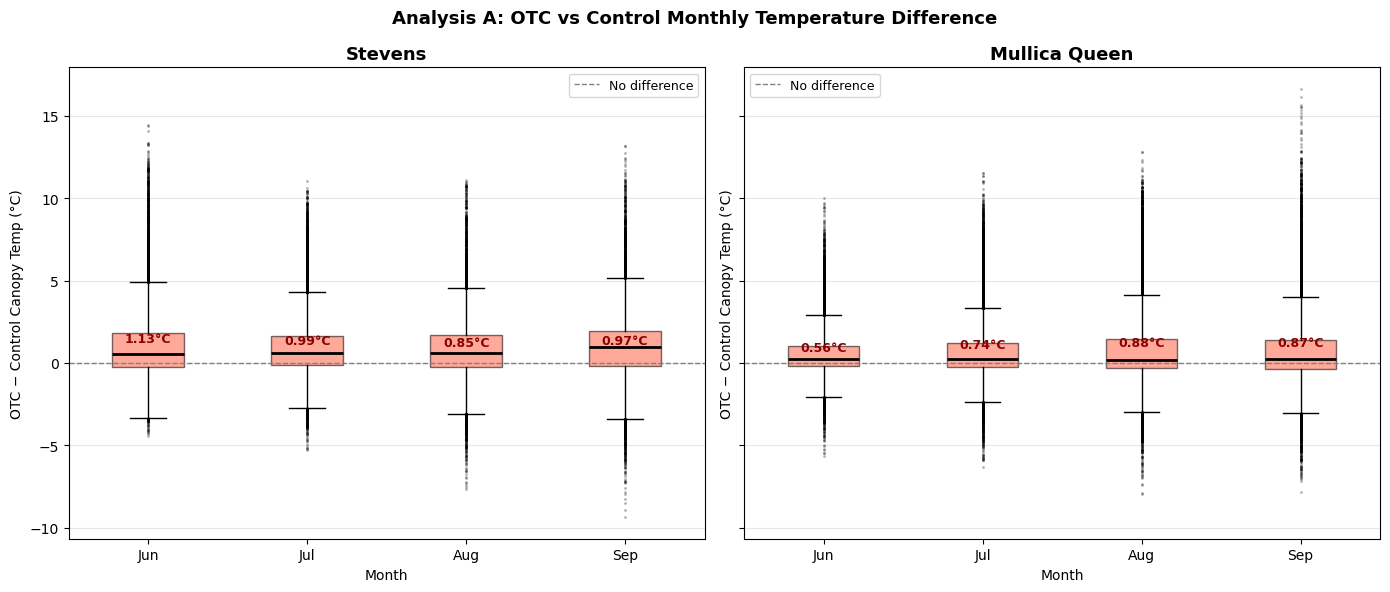

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, cultivar in zip(axes, ["St", "MQ"]):
    df_c = longterm_temperature[
        (longterm_temperature["cultivar"] == cultivar) &
        (longterm_temperature["canopy_diff"].notna())
    ]
    months = sorted(df_c["month"].unique())
    data_by_month = [df_c[df_c["month"] == m]["canopy_diff"].values for m in months]
    labels = [month_map[m] for m in months]

    bp = ax.boxplot(
        data_by_month, labels=labels, patch_artist=True,
        medianprops=dict(color="black", linewidth=2),
        flierprops=dict(marker=".", markersize=2, alpha=0.3),
    )
    for patch in bp["boxes"]:
        patch.set_facecolor("tomato")
        patch.set_alpha(0.55)

    ax.axhline(0, linestyle="--", color="gray", linewidth=1, label="No difference")

    for j, d in enumerate(data_by_month):
        mean_val = np.nanmean(d)
        ax.text(j + 1, mean_val + 0.15, f"{mean_val:.2f}°C",
                ha="center", fontsize=9, color="darkred", fontweight="bold")

    ax.set_title("Stevens" if cultivar == "St" else "Mullica Queen",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Month")
    ax.set_ylabel("OTC − Control Canopy Temp (°C)")
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle("Analysis A: OTC vs Control Monthly Temperature Difference",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Analysis A · Full-season Time Series (7-day Rolling Mean)

A 7-day rolling mean smooths day-to-day variation and shows the full-season temperature trajectory for OTC vs Control.

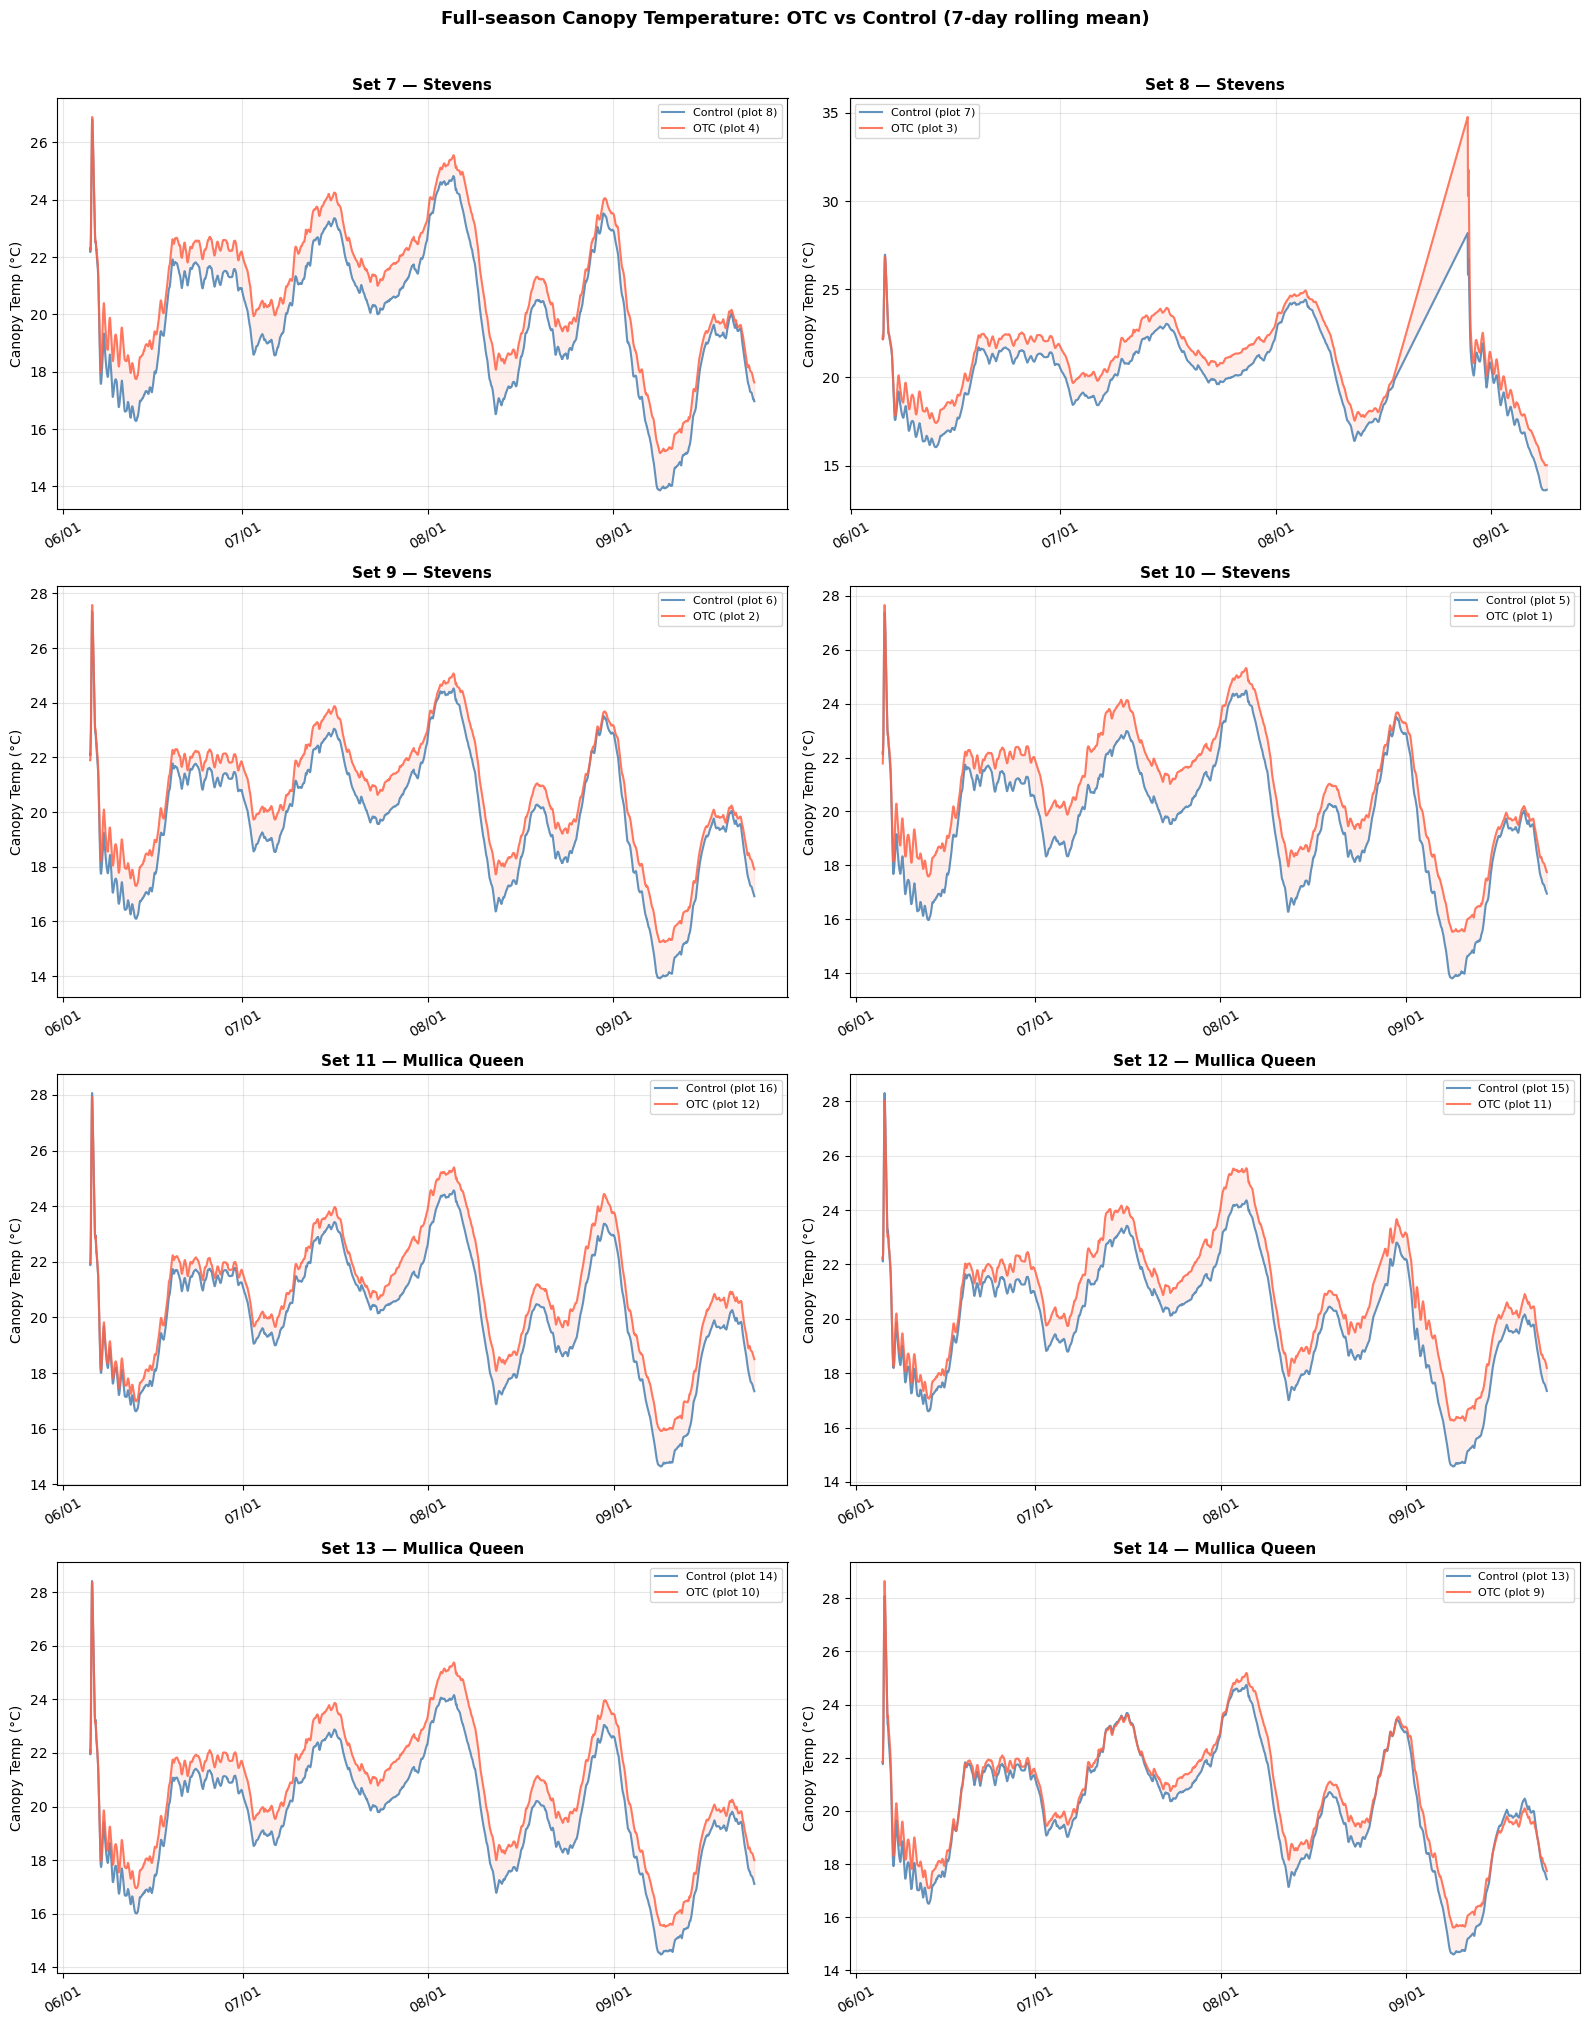

In [34]:
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, s in enumerate(sorted(longterm_temperature["set"].unique())):
    ax = axes[i]
    df_s = (
        longterm_temperature[longterm_temperature["set"] == s]
        .set_index("datetime").sort_index()
    )
    cultivar  = df_s["cultivar"].iloc[0]
    otc_plot  = df_s["otc_plot"].iloc[0]
    ctrl_plot = df_s["control_plot"].iloc[0]

    ctrl_roll = df_s["control_canopy"].rolling("7D", min_periods=1).mean()
    otc_roll  = df_s["otc_canopy"].rolling("7D", min_periods=1).mean()

    ax.plot(ctrl_roll.index, ctrl_roll.values, color="steelblue", linewidth=1.5,
            label=f"Control (plot {ctrl_plot})", alpha=0.85)
    ax.plot(otc_roll.index, otc_roll.values, color="tomato", linewidth=1.5,
            label=f"OTC (plot {otc_plot})", alpha=0.85)
    ax.fill_between(ctrl_roll.index, ctrl_roll.values, otc_roll.values,
                    alpha=0.1, color="tomato")

    ax.set_title(f"Set {s} — {'Stevens' if cultivar=='St' else 'Mullica Queen'}",
                 fontsize=11, fontweight="bold")
    ax.set_ylabel("Canopy Temp (°C)")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
    ax.grid(alpha=0.3)

plt.suptitle("Full-season Canopy Temperature: OTC vs Control (7-day rolling mean)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### Analysis B · Diurnal Pattern

Hourly average canopy temperature across the full season, revealing the temporal structure of OTC warming.
Passive OTCs rely on solar radiation for heating; warming is expected to be strong during the day and near zero at night.

In [36]:
diurnal = (
    longterm_temperature
    .groupby(["cultivar", "hour"])[["control_canopy", "otc_canopy", "canopy_diff"]]
    .mean()
    .reset_index()
)

display(diurnal[diurnal["cultivar"] == "St"].round(2))

,cultivar,hour,control_canopy,otc_canopy,canopy_diff
24,St,0,12.55,13.26,0.71
25,St,1,12.10,12.83,0.73
26,St,2,11.82,12.55,0.72
27,St,3,11.59,12.29,0.70
28,St,4,11.29,11.97,0.68
29,St,5,11.30,11.93,0.63
30,St,6,12.89,13.06,0.17
31,St,7,16.85,16.36,-0.49
32,St,8,21.04,20.19,-0.84
33,St,9,23.98,23.73,-0.24


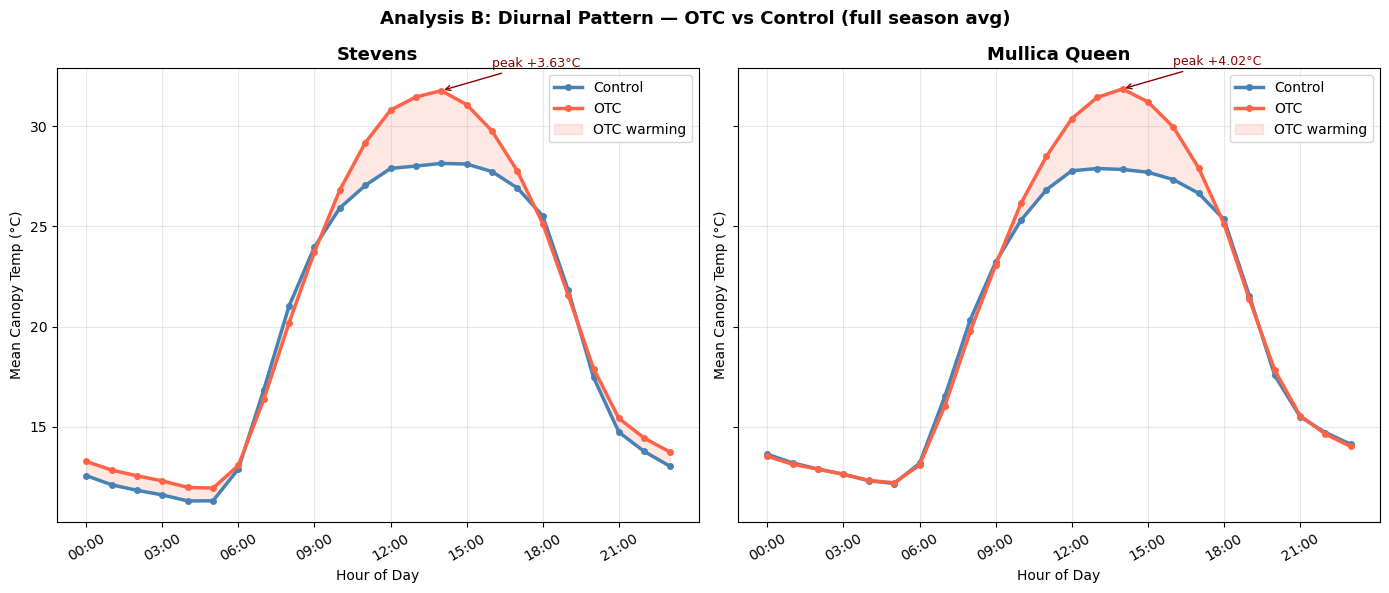

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, cultivar in zip(axes, ["St", "MQ"]):
    d = diurnal[diurnal["cultivar"] == cultivar]
    hours = d["hour"].values

    ax.plot(hours, d["control_canopy"].values, color="steelblue",
            linewidth=2.5, marker="o", markersize=4, label="Control")
    ax.plot(hours, d["otc_canopy"].values, color="tomato",
            linewidth=2.5, marker="o", markersize=4, label="OTC")
    ax.fill_between(hours, d["control_canopy"].values, d["otc_canopy"].values,
                    alpha=0.15, color="tomato", label="OTC warming")

    max_idx  = d["canopy_diff"].idxmax()
    max_hour = d.loc[max_idx, "hour"]
    max_diff = d.loc[max_idx, "canopy_diff"]
    ax.annotate(f"peak +{max_diff:.2f}°C",
                xy=(max_hour, d.loc[max_idx, "otc_canopy"]),
                xytext=(max_hour + 2, d.loc[max_idx, "otc_canopy"] + 1.2),
                arrowprops=dict(arrowstyle="->", color="darkred"),
                fontsize=9, color="darkred")

    ax.set_title("Stevens" if cultivar == "St" else "Mullica Queen",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Mean Canopy Temp (°C)")
    ax.set_xticks(range(0, 24, 3))
    ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 3)], rotation=30)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle("Analysis B: Diurnal Pattern — OTC vs Control (full season avg)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Analysis C · Seasonal Trend (Weekly Mean ± 1 SD)

Weekly temperature difference aggregation to test whether warming magnitude changes systematically across the growing season.
Wide ±1 SD bands reflect day-to-day variability driven by cloud cover, wind speed, and other environmental conditions.

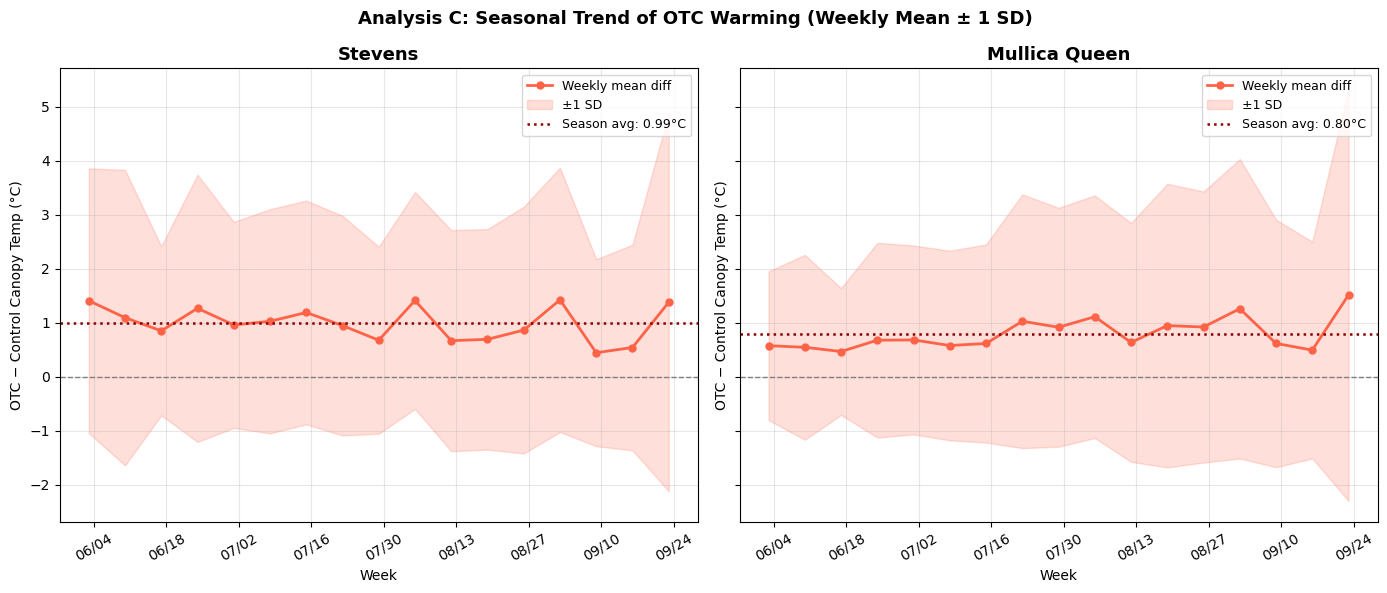

In [39]:
weekly_diff = (
    longterm_temperature
    .groupby(["cultivar", "week"])["canopy_diff"]
    .agg(mean="mean", std="std", count="count")
    .reset_index()
)
weekly_diff["week_start"] = weekly_diff["week"].dt.start_time

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, cultivar in zip(axes, ["St", "MQ"]):
    d = weekly_diff[weekly_diff["cultivar"] == cultivar].sort_values("week_start")

    ax.plot(d["week_start"], d["mean"], color="tomato",
            linewidth=2, marker="o", markersize=5, label="Weekly mean diff")
    ax.fill_between(d["week_start"],
                    d["mean"] - d["std"], d["mean"] + d["std"],
                    alpha=0.2, color="tomato", label="±1 SD")
    ax.axhline(0, linestyle="--", color="gray", linewidth=1)

    season_mean = d["mean"].mean()
    ax.axhline(season_mean, linestyle=":", color="darkred", linewidth=1.8,
               label=f"Season avg: {season_mean:.2f}°C")

    ax.set_title("Stevens" if cultivar == "St" else "Mullica Queen",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Week")
    ax.set_ylabel("OTC − Control Canopy Temp (°C)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Analysis C: Seasonal Trend of OTC Warming (Weekly Mean ± 1 SD)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Analysis D · Fruit Sensor Data Quality

Visualize the daily fraction of valid readings from the fruit sensors in each set.
Used to assess the reliability of fruit temperature data and guide selection of covariates for yield/concentration analysis.

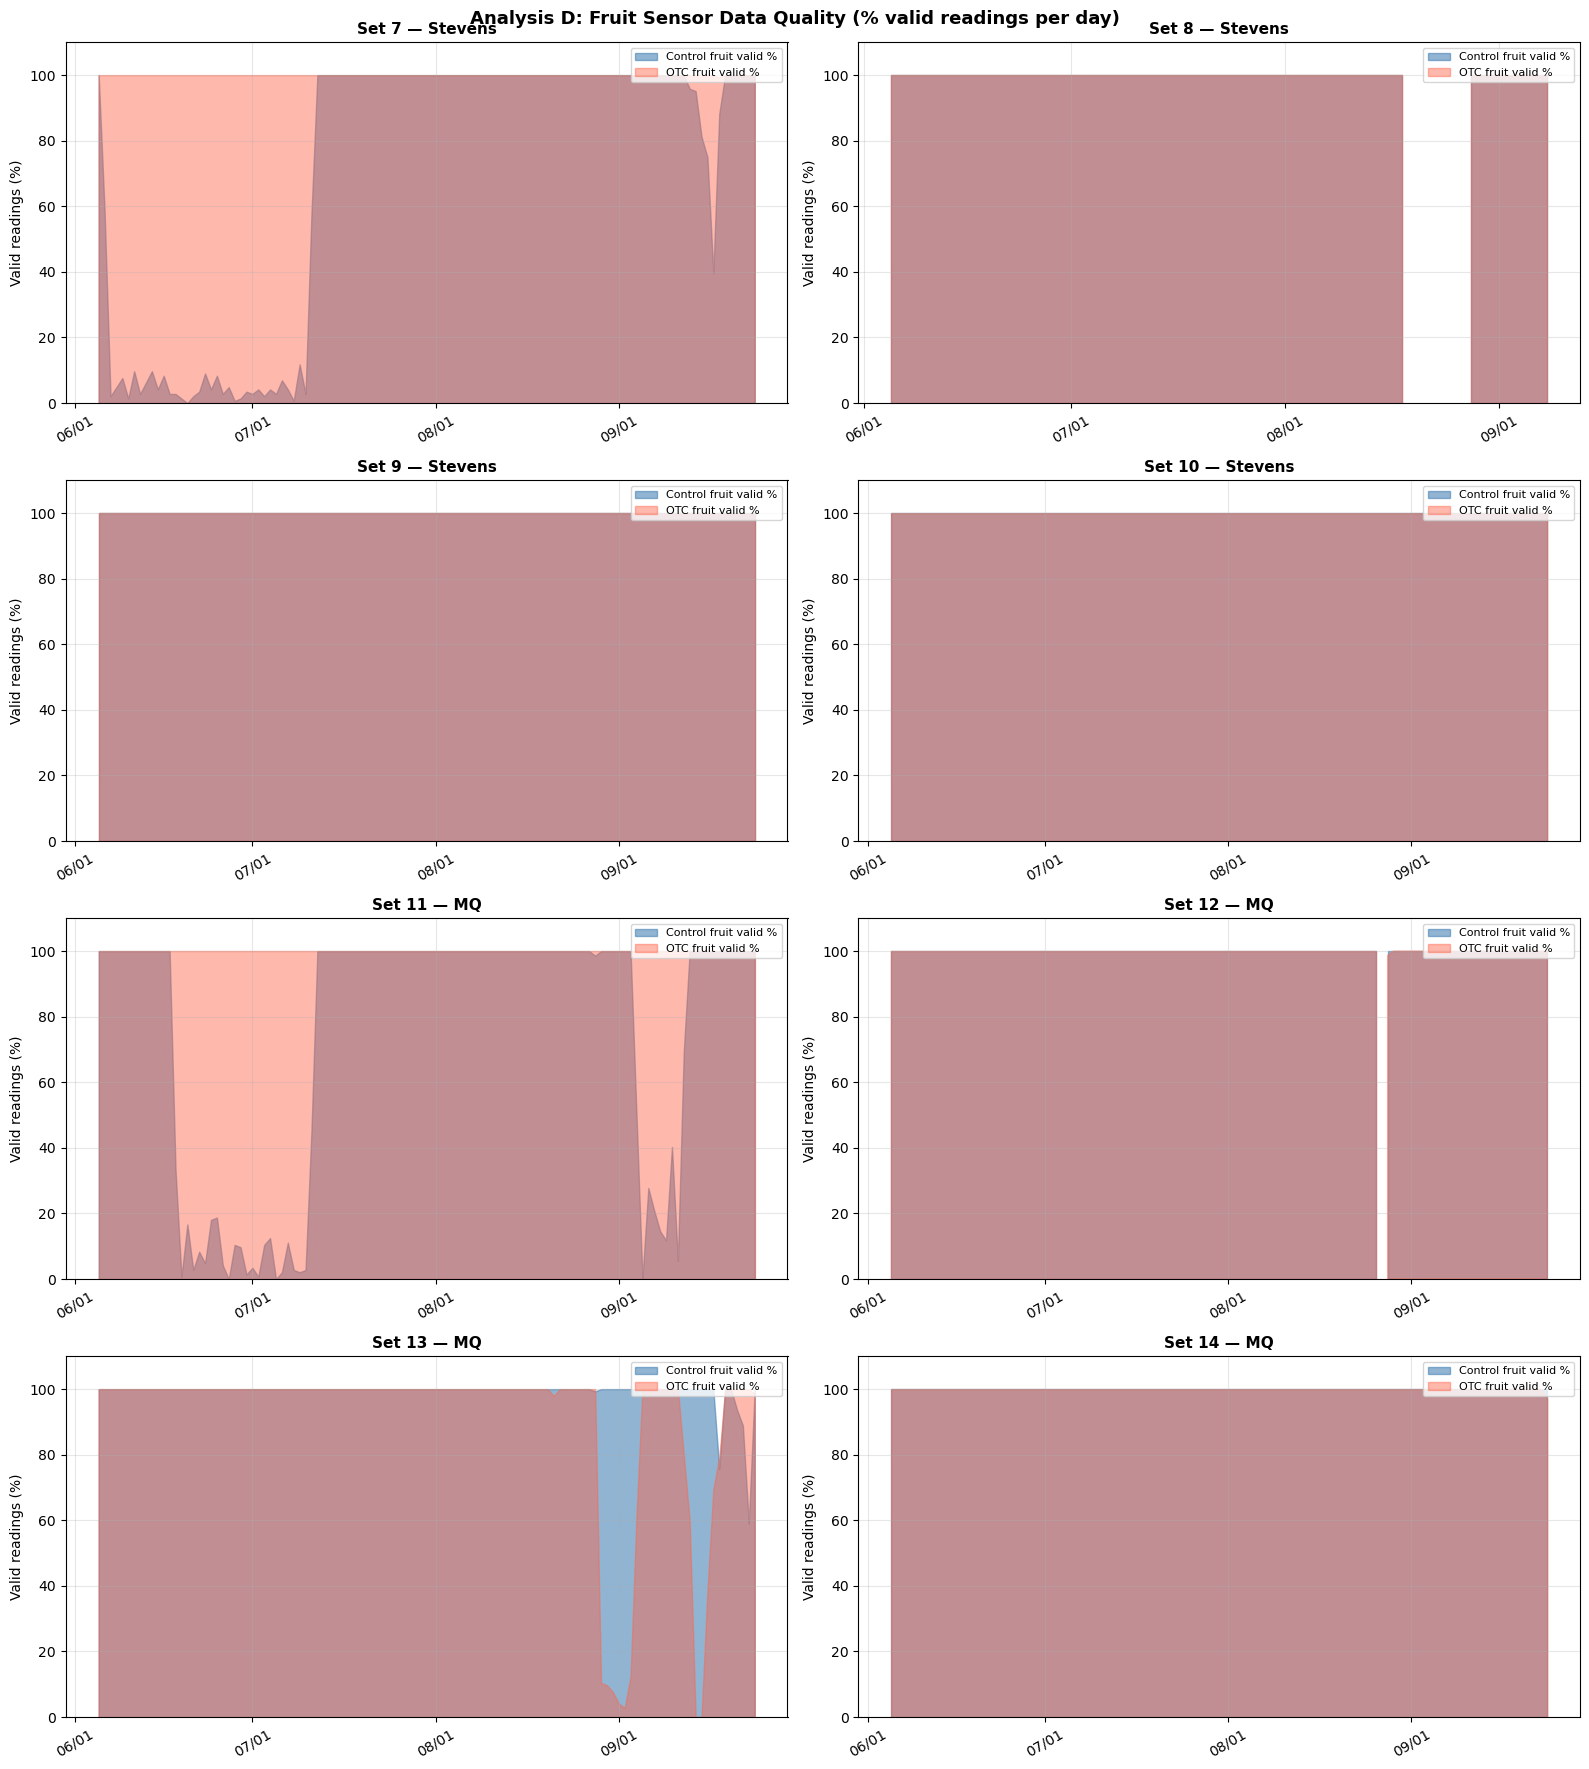

In [41]:
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for i, s in enumerate(sorted(longterm_temperature["set"].unique())):
    ax = axes[i]
    df_s = (
        longterm_temperature[longterm_temperature["set"] == s]
        .set_index("datetime").sort_index()
    )
    cultivar = df_s["cultivar"].iloc[0]

    ctrl_valid = df_s["control_fruit"].notna().astype(int).resample("D").mean() * 100
    otc_valid  = df_s["otc_fruit"].notna().astype(int).resample("D").mean() * 100

    ax.fill_between(ctrl_valid.index, ctrl_valid.values,
                    alpha=0.6, color="steelblue", label="Control fruit valid %")
    ax.fill_between(otc_valid.index, otc_valid.values,
                    alpha=0.45, color="tomato", label="OTC fruit valid %")

    ax.set_ylim(0, 110)
    ax.set_title(f"Set {s} — {'Stevens' if cultivar=='St' else 'MQ'}",
                 fontsize=11, fontweight="bold")
    ax.set_ylabel("Valid readings (%)")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
    ax.grid(alpha=0.3)

plt.suptitle("Analysis D: Fruit Sensor Data Quality (% valid readings per day)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Key Observations from Plots A–D

**Plot 1 (Full-season time series) → OTC does warm, but moderately and with variability**
In all 8 sets, OTC canopy temperature (orange) remains consistently above the control (blue). Set 8 shows an obvious anomalous spike in late September, which has been truncated.

**Plot 2 (Diurnal pattern) → Warming is concentrated during daytime (9–17 h), peaking around noon**
Stevens peak midday warming ~+3.65°C; Mullica Queen ~+4.02°C. At night the two lines nearly overlap — OTC provides no insulation — consistent with the passive heating mechanism.

**Plot 3 (Seasonal trend) → Full-season mean warming ~+0.8–1.0°C with high week-to-week variability**
Stevens full-season mean +0.98°C; MQ +0.77°C. The wide ±1 SD band reflects high between-week variability driven by cloud cover and wind.

**Plot 4 (Data quality) → Fruit sensors partially faulty; canopy data reliable**
Sets 7 and 11 control_fruit sensors have extended outages in June–July. All canopy channels across all sets show >99% valid readings; subsequent analysis prioritizes canopy temperature.

## 8. Summary Statistics Tables

Three summary tables for use in the report and Task 1 yield analysis:
1. `paired_table` — per-set paired temperature difference statistics (full season + daytime)
2. `perf_summary` — cultivar-level performance summary
3. `monthly_paired` — monthly paired summary

In [44]:
paired_rows = []

for s in sorted(longterm_temperature["set"].unique()):
    df_s = longterm_temperature[longterm_temperature["set"] == s].copy()
    cultivar = df_s["cultivar"].iloc[0]
    valid = df_s[["datetime","control_canopy","otc_canopy","canopy_diff","hour"]]\
            .dropna(subset=["control_canopy","otc_canopy"])

    paired_rows.append({
        "set": s, "cultivar": cultivar, "period": "Full season",
        "n": len(valid),
        "control_mean": round(valid["control_canopy"].mean(), 2),
        "otc_mean":     round(valid["otc_canopy"].mean(), 2),
        "delta_mean":   round(valid["canopy_diff"].mean(), 3),
        "delta_max":    round(valid["canopy_diff"].max(), 2),
        "delta_min":    round(valid["canopy_diff"].min(), 2),
        "pct_otc_gt_ctrl": round((valid["canopy_diff"] > 0).mean() * 100, 1),
    })

    daytime = valid[valid["hour"].between(9, 17)]
    paired_rows.append({
        "set": s, "cultivar": cultivar, "period": "Daytime (9-17h)",
        "n": len(daytime),
        "control_mean": round(daytime["control_canopy"].mean(), 2),
        "otc_mean":     round(daytime["otc_canopy"].mean(), 2),
        "delta_mean":   round(daytime["canopy_diff"].mean(), 3),
        "delta_max":    round(daytime["canopy_diff"].max(), 2),
        "delta_min":    round(daytime["canopy_diff"].min(), 2),
        "pct_otc_gt_ctrl": round((daytime["canopy_diff"] > 0).mean() * 100, 1),
    })

paired_table = pd.DataFrame(paired_rows)
display(paired_table)

,set,cultivar,period,n,control_mean,otc_mean,delta_mean,delta_max,delta_min,pct_otc_gt_ctrl
0,7,St,Full season,15990,19.76,20.73,0.968,13.19,-9.38,69.9
1,7,St,Daytime (9-17h),6000,27.68,29.85,2.170,13.19,-9.38,83.3
2,8,St,Full season,12231,19.70,20.70,1.005,14.43,-7.69,67.8
3,8,St,Daytime (9-17h),4585,26.63,29.04,2.411,14.43,-6.41,84.9
4,9,St,Full season,15988,19.61,20.48,0.863,12.38,-5.79,67.1
5,9,St,Daytime (9-17h),5998,26.94,28.51,1.568,12.38,-5.79,71.1
6,10,St,Full season,15991,19.55,20.64,1.095,12.13,-7.16,68.5
7,10,St,Daytime (9-17h),6001,27.02,29.23,2.214,12.13,-7.16,83.7
8,11,MQ,Full season,15976,19.95,20.75,0.801,16.65,-3.91,62.2
9,11,MQ,Daytime (9-17h),5986,26.80,28.85,2.051,16.65,-3.28,81.8


In [45]:
def perf_by_period(df, period_name):
    return (
        df.dropna(subset=["control_canopy","otc_canopy"])
        .groupby("cultivar")
        .agg(
            n               =("canopy_diff","count"),
            control_mean    =("control_canopy","mean"),
            otc_mean        =("otc_canopy","mean"),
            delta_mean      =("canopy_diff","mean"),
            delta_median    =("canopy_diff","median"),
            delta_std       =("canopy_diff","std"),
            delta_max       =("canopy_diff","max"),
            pct_otc_gt_ctrl =("canopy_diff", lambda x: (x > 0).mean() * 100),
        )
        .round(3)
        .reset_index()
        .assign(period=period_name)
    )

lt = longterm_temperature
perf_summary = pd.concat([
    perf_by_period(lt,                                    "Full season"),
    perf_by_period(lt[lt["hour"].between(9,17)],          "Daytime (9-17h)"),
    perf_by_period(lt[~lt["hour"].between(9,17)],         "Nighttime"),
], ignore_index=True)

perf_summary = perf_summary[["cultivar","period","n","control_mean","otc_mean",
                               "delta_mean","delta_median","delta_std",
                               "delta_max","pct_otc_gt_ctrl"]]

display(perf_summary)

,cultivar,period,n,control_mean,otc_mean,delta_mean,delta_median,delta_std,delta_max,pct_otc_gt_ctrl
0,MQ,Full season,63619,19.839,20.606,0.767,0.21,2.141,16.65,60.361
1,St,Full season,60200,19.654,20.635,0.981,0.64,2.158,14.43,68.362
2,MQ,Daytime (9-17h),23839,26.736,28.953,2.217,1.67,2.691,16.65,84.089
3,St,Daytime (9-17h),22584,27.093,29.164,2.071,1.54,2.752,14.43,80.477
4,MQ,Nighttime,39780,15.706,15.604,-0.102,-0.04,0.989,6.19,46.141
5,St,Nighttime,37616,15.187,15.514,0.327,0.31,1.327,5.81,61.088


In [46]:
monthly_paired = (
    longterm_temperature
    .dropna(subset=["control_canopy","otc_canopy"])
    .groupby(["cultivar","month_label"])
    .agg(
        n               =("canopy_diff","count"),
        delta_mean      =("canopy_diff","mean"),
        delta_median    =("canopy_diff","median"),
        delta_std       =("canopy_diff","std"),
        delta_max       =("canopy_diff","max"),
        pct_otc_gt_ctrl =("canopy_diff", lambda x: (x > 0).mean() * 100),
    )
    .round(3)
    .reset_index()
)

month_order = ["Jun","Jul","Aug","Sep"]
monthly_paired["month_label"] = pd.Categorical(
    monthly_paired["month_label"], categories=month_order, ordered=True
)
monthly_paired = monthly_paired.sort_values(["cultivar","month_label"]).reset_index(drop=True)

display(monthly_paired)

,cultivar,month_label,n,delta_mean,delta_median,delta_std,delta_max,pct_otc_gt_ctrl
0,MQ,Jun,14664,0.564,0.23,1.554,9.99,62.984
1,MQ,Jul,17856,0.738,0.22,1.978,11.53,61.817
2,MQ,Aug,17573,0.882,0.19,2.335,12.82,58.698
3,MQ,Sep,13526,0.874,0.21,2.575,16.65,57.755
4,St,Jun,14664,1.129,0.54,2.346,14.43,65.248
5,St,Jul,17853,0.989,0.62,1.992,11.05,70.778
6,St,Aug,16341,0.846,0.58,2.012,11.10,67.224
7,St,Sep,11342,0.974,0.94,2.338,13.19,70.226


## 9. Supplementary Visualizations

Show between-set variability in temperature difference (violin plot) and daytime vs nighttime warming comparison.
These plots directly support the discussion of between-set variability in the report.

### Between-Set Variability (Violin Plot)

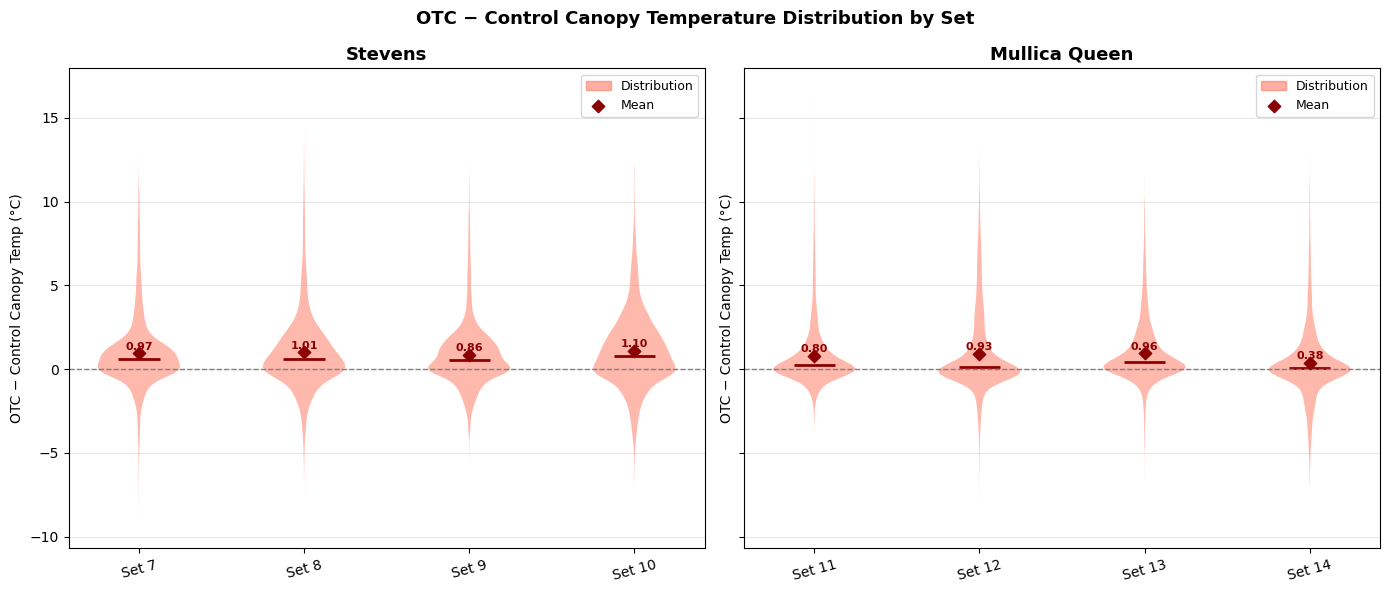

In [49]:
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, cultivar in zip(axes, ["St","MQ"]):
    df_c = longterm_temperature[
        (longterm_temperature["cultivar"] == cultivar) &
        (longterm_temperature["canopy_diff"].notna())
    ]
    sets_c    = sorted(df_c["set"].unique())
    data_list = [df_c[df_c["set"] == s]["canopy_diff"].values for s in sets_c]
    positions = list(range(1, len(sets_c) + 1))

    vp = ax.violinplot(data_list, positions=positions, showmedians=True, showextrema=False)
    for body in vp["bodies"]:
        body.set_facecolor("tomato"); body.set_alpha(0.45)
    vp["cmedians"].set_color("darkred"); vp["cmedians"].set_linewidth(2)

    for pos, data in zip(positions, data_list):
        mean_val = data.mean()
        ax.scatter(pos, mean_val, color="darkred", zorder=5, s=40, marker="D")
        ax.text(pos, mean_val + 0.2, f"{mean_val:.2f}",
                ha="center", fontsize=8, color="darkred", fontweight="bold")

    ax.axhline(0, linestyle="--", color="gray", linewidth=1)
    ax.set_xticks(positions)
    ax.set_xticklabels([f"Set {s}" for s in sets_c], rotation=15)
    ax.set_title("Stevens" if cultivar == "St" else "Mullica Queen",
                 fontsize=13, fontweight="bold")
    ax.set_ylabel("OTC − Control Canopy Temp (°C)")
    ax.grid(axis="y", alpha=0.3)

    patch   = mpatches.Patch(color="tomato", alpha=0.5, label="Distribution")
    diamond = ax.scatter([], [], color="darkred", marker="D", s=40, label="Mean")
    ax.legend(handles=[patch, diamond], fontsize=9)

plt.suptitle("OTC − Control Canopy Temperature Distribution by Set",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Daytime vs Nighttime Warming Effect

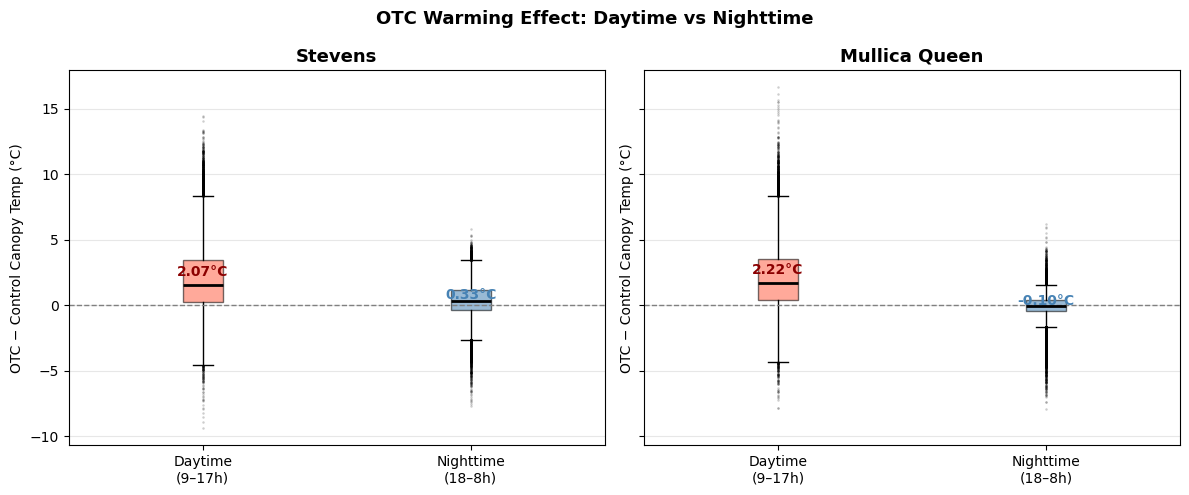

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, cultivar in zip(axes, ["St","MQ"]):
    df_c = longterm_temperature[
        (longterm_temperature["cultivar"] == cultivar) &
        (longterm_temperature["canopy_diff"].notna())
    ].copy()

    day   = df_c[df_c["hour"].between(9, 17)]["canopy_diff"]
    night = df_c[~df_c["hour"].between(9, 17)]["canopy_diff"]

    bp = ax.boxplot(
        [day, night],
        labels=["Daytime\n(9–17h)", "Nighttime\n(18–8h)"],
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2),
        flierprops=dict(marker=".", markersize=1.5, alpha=0.2),
    )
    for patch, c in zip(bp["boxes"], ["tomato","steelblue"]):
        patch.set_facecolor(c); patch.set_alpha(0.55)

    for i, (data, col) in enumerate([(day,"darkred"),(night,"steelblue")], start=1):
        ax.text(i, data.mean() + 0.15, f"{data.mean():.2f}°C",
                ha="center", fontsize=10, fontweight="bold", color=col)

    ax.axhline(0, linestyle="--", color="gray", linewidth=1)
    ax.set_title("Stevens" if cultivar == "St" else "Mullica Queen",
                 fontsize=13, fontweight="bold")
    ax.set_ylabel("OTC − Control Canopy Temp (°C)")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("OTC Warming Effect: Daytime vs Nighttime",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 10. Printed Summary for Report

Key numbers aggregated here for direct use in the executive summary and technical report.

In [53]:
print("=" * 60)
print("LONG-TERM EXPERIMENT — TEMPERATURE CONTROL SUMMARY")
print("=" * 60)

for _, row in perf_summary[perf_summary["period"] == "Full season"].iterrows():
    cv = "Stevens" if row["cultivar"] == "St" else "Mullica Queen"
    print(f"  {cv}: mean={row['delta_mean']}°C, median={row['delta_median']}°C, "
          f"SD={row['delta_std']}°C, OTC>Control: {row['pct_otc_gt_ctrl']}% of time")

for _, row in perf_summary[perf_summary["period"] == "Daytime (9-17h)"].iterrows():
    cv = "Stevens" if row["cultivar"] == "St" else "Mullica Queen"
    print(f"  {cv}: mean={row['delta_mean']}°C, max single reading={row['delta_max']}°C")

for _, row in perf_summary[perf_summary["period"] == "Nighttime"].iterrows():
    cv = "Stevens" if row["cultivar"] == "St" else "Mullica Queen"

LONG-TERM EXPERIMENT — TEMPERATURE CONTROL SUMMARY
  Mullica Queen: mean=0.767°C, median=0.21°C, SD=2.141°C, OTC>Control: 60.361% of time
  Stevens: mean=0.981°C, median=0.64°C, SD=2.158°C, OTC>Control: 68.362% of time
  Mullica Queen: mean=2.217°C, max single reading=16.65°C
  Stevens: mean=2.071°C, max single reading=14.43°C


## 11. HOBO Humidity Analysis

HOBO sensors also record relative humidity (RH), a dimension unique to the long-term experiment.
Analysis objectives:
- OTC vs Control RH difference (does OTC also affect humidity?)
- Relationship between RH and temperature difference

**Motivation for Task 1:** Humidity affects berry quality and rot rate. If OTC systematically alters RH in addition to temperature, this should be considered when interpreting yield outcomes.

In [55]:
hobo_summary = (
    hobo_data
    .dropna(subset=["temperature", "humidity"])
    .groupby(["cultivar", "treatment"])
    .agg(
        n           = ("humidity", "count"),
        temp_mean   = ("temperature", "mean"),
        temp_std    = ("temperature", "std"),
        rh_mean     = ("humidity", "mean"),
        rh_std      = ("humidity", "std"),
    )
    .round(3)
    .reset_index()
)
print("HOBO OTC vs Control — Temperature & Humidity Summary:")
display(hobo_summary)

HOBO OTC vs Control — Temperature & Humidity Summary:


,cultivar,treatment,n,temp_mean,temp_std,rh_mean,rh_std
0,MQ,Control,55764,19.649,6.302,80.498,14.611
1,MQ,OTC,55357,19.640,6.141,82.051,12.726
2,St,Control,54934,19.246,6.978,82.590,13.936
3,St,OTC,54521,19.725,6.740,84.949,12.750


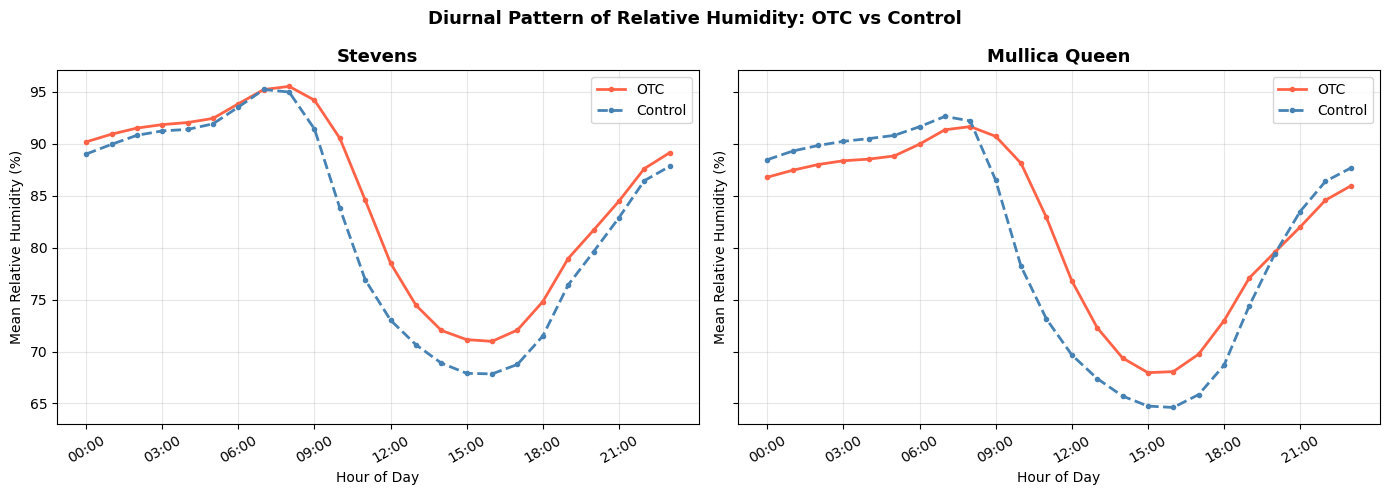

In [56]:
hobo_data["hour"] = hobo_data["datetime"].dt.hour

diurnal_rh = (
    hobo_data
    .dropna(subset=["humidity"])
    .groupby(["cultivar", "treatment", "hour"])["humidity"]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, cultivar in zip(axes, ["St", "MQ"]):
    d = diurnal_rh[diurnal_rh["cultivar"] == cultivar]
    for trt, color, ls in [("OTC", "tomato", "-"), ("Control", "steelblue", "--")]:
        sub = d[d["treatment"] == trt]
        ax.plot(sub["hour"], sub["humidity"], color=color,
                linestyle=ls, linewidth=2, marker="o", markersize=3, label=trt)

    ax.set_title("Stevens" if cultivar == "St" else "Mullica Queen",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Mean Relative Humidity (%)")
    ax.set_xticks(range(0, 24, 3))
    ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 3)], rotation=30)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle("Diurnal Pattern of Relative Humidity: OTC vs Control",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

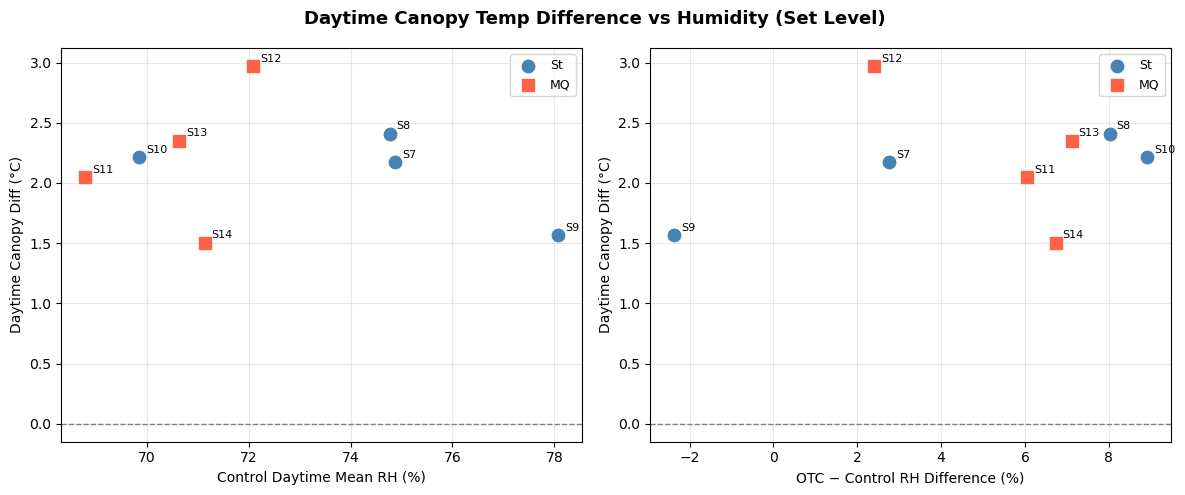

Set-level merged table:


,set,cultivar,canopy_diff_mean,rh_control,rh_otc,rh_diff
0,7,St,2.170,74.881,77.643,2.762
1,8,St,2.411,74.766,82.787,8.021
2,9,St,1.568,78.078,75.707,-2.371
3,10,St,2.214,69.851,78.764,8.913
4,11,MQ,2.051,68.787,74.845,6.057
5,12,MQ,2.972,72.084,74.492,2.408
6,13,MQ,2.352,70.641,77.752,7.111
7,14,MQ,1.506,71.136,77.866,6.730


In [57]:
set_day = (
    longterm_temperature
    .loc[
        longterm_temperature["hour"].between(9, 17) &
        longterm_temperature["control_canopy"].notna() &
        longterm_temperature["otc_canopy"].notna()
    ]
    .groupby(["set", "cultivar"])
    .agg(
        canopy_diff_mean = ("canopy_diff", "mean"),
    )
    .reset_index()
)

hobo_day = (
    hobo_data
    .loc[hobo_data["hour"].between(9, 17) & hobo_data["humidity"].notna()]
    .groupby(["set", "treatment"])["humidity"]
    .mean()
    .reset_index()
)
hobo_day_ctrl = hobo_day[hobo_day["treatment"]=="Control"][["set","humidity"]].rename(columns={"humidity":"rh_control"})
hobo_day_otc  = hobo_day[hobo_day["treatment"]=="OTC"]  [["set","humidity"]].rename(columns={"humidity":"rh_otc"})
hobo_day_wide = hobo_day_ctrl.merge(hobo_day_otc, on="set", how="outer")
hobo_day_wide["rh_diff"] = hobo_day_wide["rh_otc"] - hobo_day_wide["rh_control"]

set_merged = set_day.merge(hobo_day_wide, on="set", how="left")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (xcol, xlabel) in zip(axes, [
    ("rh_control", "Control Daytime Mean RH (%)"),
    ("rh_diff",    "OTC − Control RH Difference (%)"),
]):
    for cultivar, marker, color in [("St", "o", "steelblue"), ("MQ", "s", "tomato")]:
        sub = set_merged[set_merged["cultivar"] == cultivar]
        ax.scatter(sub[xcol], sub["canopy_diff_mean"],
                   marker=marker, color=color, s=80, label=cultivar, zorder=5)
        for _, row in sub.iterrows():
            ax.annotate(f"S{int(row['set'])}",
                        (row[xcol], row["canopy_diff_mean"]),
                        textcoords="offset points", xytext=(5, 3), fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Daytime Canopy Diff (°C)")
    ax.axhline(0, linestyle="--", color="gray", linewidth=1)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Daytime Canopy Temp Difference vs Humidity (Set Level)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Set-level merged table:")
display(set_merged.round(3))

## 12. Warming Success Indicators

Analogous to the `hit_40_any` and `stable_40` metrics in the acute experiment, the following success criteria are defined for the long-term experiment:

| Metric | Definition |
|--------|-----------|
| `warming_positive` | Fraction of the full season where OTC > Control |
| `daytime_mean_diff` | Mean daytime (9–17 h) temperature difference |
| `success_daytime` | Daytime mean difference ≥ 1.5°C (a reasonable threshold for passive OTC) |
| `wilcoxon_p` | One-sample Wilcoxon test: whether `canopy_diff` is significantly > 0 |

**Rationale:** Unlike the acute experiment where 40°C is the explicit target, the long-term OTC is a passive warming device with no fixed temperature goal. We define success as a daytime warming of ≥ 1.5°C, consistent with the passive solar heating mechanism.

In [59]:
success_rows = []

for s in sorted(longterm_temperature["set"].unique()):
    df_s = longterm_temperature[longterm_temperature["set"] == s].copy()
    cultivar = df_s["cultivar"].iloc[0]
    valid = df_s.dropna(subset=["control_canopy", "otc_canopy"])
    day   = valid[valid["hour"].between(9, 17)]

    pct_positive = (valid["canopy_diff"] > 0).mean()

    day_diff_mean = day["canopy_diff"].mean()

    success_daytime = day_diff_mean >= 1.5

    diff_vals = valid["canopy_diff"].dropna().values
    sample = diff_vals if len(diff_vals) <= 5000 else \
             diff_vals[::len(diff_vals)//5000]
    stat, p_val = stats.wilcoxon(sample, alternative="greater")

    success_rows.append({
        "set"              : s,
        "cultivar"         : cultivar,
        "n_valid"          : len(valid),
        "pct_otc_gt_ctrl"  : round(pct_positive * 100, 1),
        "daytime_diff_mean": round(day_diff_mean, 3),
        "success_daytime"  : success_daytime,
        "wilcoxon_p"       : round(p_val, 4),
        "sig_warming"      : p_val < 0.05,
    })

success_table = pd.DataFrame(success_rows)
print("Warming Success Indicators per Set:")
display(success_table)

n_success = success_table["success_daytime"].sum()
n_sig     = success_table["sig_warming"].sum()
print(f"\n✅ {n_success}/8 sets met the daytime warming threshold (≥1.5°C)")
print(f"✅ {n_sig}/8 sets showed statistically significant warming (Wilcoxon p<0.05)")

Warming Success Indicators per Set:


,set,cultivar,n_valid,pct_otc_gt_ctrl,daytime_diff_mean,success_daytime,wilcoxon_p,sig_warming
0,7,St,15990,69.9,2.170,True,0.0,True
1,8,St,12231,67.8,2.411,True,0.0,True
2,9,St,15988,67.1,1.568,True,0.0,True
3,10,St,15991,68.5,2.214,True,0.0,True
4,11,MQ,15976,62.2,2.051,True,0.0,True
5,12,MQ,15693,55.2,2.972,True,0.0,True
6,13,MQ,15975,70.5,2.352,True,0.0,True
7,14,MQ,15975,53.5,1.506,True,0.0,True



✅ 8/8 sets met the daytime warming threshold (≥1.5°C)
✅ 8/8 sets showed statistically significant warming (Wilcoxon p<0.05)


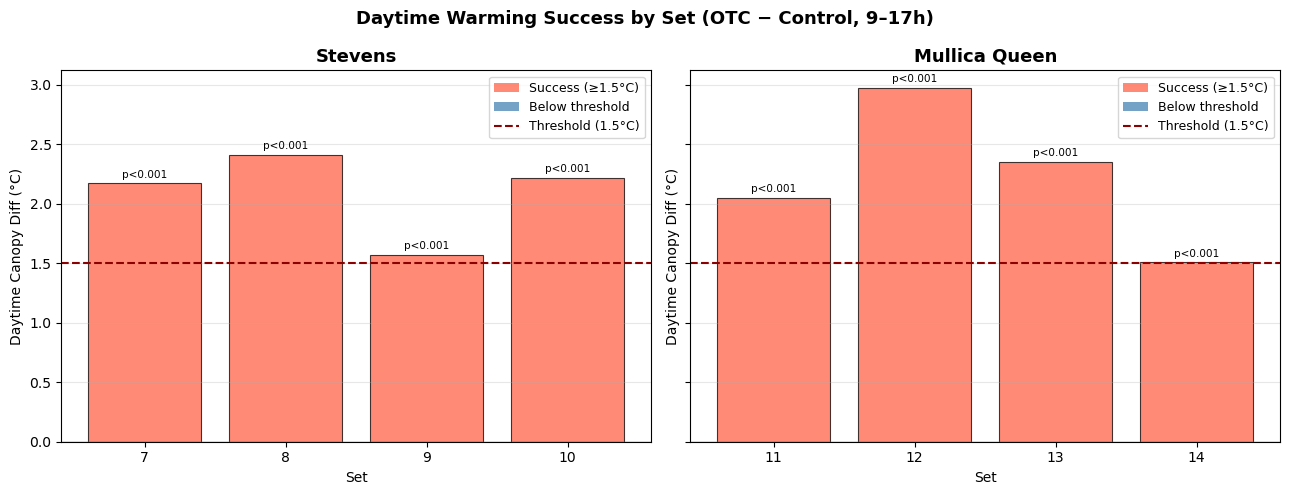

In [60]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, cultivar in zip(axes, ["St", "MQ"]):
    sub = success_table[success_table["cultivar"] == cultivar].sort_values("set")
    colors = ["tomato" if v else "steelblue" for v in sub["success_daytime"]]
    ax.bar(sub["set"].astype(str), sub["daytime_diff_mean"],
           color=colors, alpha=0.75, edgecolor="black", linewidth=0.8)

    ax.axhline(1.5, linestyle="--", color="darkred", linewidth=1.5)
    ax.axhline(0,   linestyle="-",  color="gray",    linewidth=1)

    for _, row in sub.iterrows():
        label = f"p={row['wilcoxon_p']}" if row['wilcoxon_p'] >= 0.001 else "p<0.001"
        ax.text(str(row["set"]), row["daytime_diff_mean"] + 0.05,
                label, ha="center", fontsize=7.5, color="black")

    ax.set_title("Stevens" if cultivar == "St" else "Mullica Queen",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Set")
    ax.set_ylabel("Daytime Canopy Diff (°C)")
    ax.grid(axis="y", alpha=0.3)

    legend_elements = [
        Patch(facecolor="tomato",    alpha=0.75, label="Success (≥1.5°C)"),
        Patch(facecolor="steelblue", alpha=0.75, label="Below threshold"),
        plt.Line2D([0],[0], linestyle="--", color="darkred", label="Threshold (1.5°C)"),
    ]
    ax.legend(handles=legend_elements, fontsize=9)

plt.suptitle("Daytime Warming Success by Set (OTC − Control, 9–17h)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 13. Plot-level Temperature Covariates for Task 1 (Yield Analysis)

Aggregate temperature data to a **plot-level** covariate table for direct merging in Task 1 yield analysis.

One row per plot, including:

| Variable | Description |
|----------|-------------|
| `canopy_mean_full` | Full-season mean canopy temperature |
| `canopy_mean_daytime` | Daytime (9–17 h) mean canopy temperature |
| `canopy_diff_mean` | Full-season OTC−Control mean (set level, shared by OTC and Control plots) |
| `canopy_diff_daytime` | Daytime OTC−Control mean |
| `canopy_diff_sd` | Full-season temperature difference SD (reflects OTC control stability) |
| `rh_mean_daytime` | Daytime mean relative humidity (HOBO) |

**Usage in Task 1:** These covariates can be merged into the yield dataframe on `plot` to explore whether between-set temperature variation explains residual variance in healthy weight or rot percentage.

In [62]:
cov_rows = []

for s in sorted(longterm_temperature["set"].unique()):
    df_s   = longterm_temperature[longterm_temperature["set"] == s]
    cultivar   = df_s["cultivar"].iloc[0]
    otc_plot   = df_s["otc_plot"].iloc[0]
    ctrl_plot  = df_s["control_plot"].iloc[0]
    valid      = df_s.dropna(subset=["control_canopy", "otc_canopy"])
    day        = valid[valid["hour"].between(9, 17)]

    diff_mean     = valid["canopy_diff"].mean()
    diff_daytime  = day["canopy_diff"].mean()
    diff_sd       = valid["canopy_diff"].std()

    # OTC plot
    cov_rows.append({
        "plot"               : otc_plot,
        "set"                : s,
        "cultivar"           : cultivar,
        "treatment"          : "OTC",
        "canopy_mean_full"   : round(valid["otc_canopy"].mean(), 3),
        "canopy_mean_daytime": round(day["otc_canopy"].mean(), 3),
        "canopy_diff_mean"   : round(diff_mean, 3),
        "canopy_diff_daytime": round(diff_daytime, 3),
        "canopy_diff_sd"     : round(diff_sd, 3),
    })
    # Control plot
    cov_rows.append({
        "plot"               : ctrl_plot,
        "set"                : s,
        "cultivar"           : cultivar,
        "treatment"          : "Control",
        "canopy_mean_full"   : round(valid["control_canopy"].mean(), 3),
        "canopy_mean_daytime": round(day["control_canopy"].mean(), 3),
        "canopy_diff_mean"   : round(diff_mean, 3),
        "canopy_diff_daytime": round(diff_daytime, 3),
        "canopy_diff_sd"     : round(diff_sd, 3),
    })

cov_df = pd.DataFrame(cov_rows).sort_values("plot").reset_index(drop=True)

rh_plot = (
    hobo_data
    .loc[hobo_data["hour"].between(9, 17) & hobo_data["humidity"].notna()]
    .groupby("plot")["humidity"]
    .mean()
    .round(3)
    .reset_index()
    .rename(columns={"humidity": "rh_mean_daytime"})
)

cov_df = cov_df.merge(rh_plot, on="plot", how="left")

print(f"lt_temp_covariates: {cov_df.shape[0]} rows × {cov_df.shape[1]} cols")
display(cov_df)

lt_temp_covariates: 16 rows × 10 cols


,plot,set,cultivar,treatment,canopy_mean_full,canopy_mean_daytime,canopy_diff_mean,canopy_diff_daytime,canopy_diff_sd,rh_mean_daytime
0,1,10,St,OTC,20.644,29.231,1.095,2.214,2.235,78.764
1,2,9,St,OTC,20.478,28.507,0.863,1.568,1.961,75.707
2,3,8,St,OTC,20.704,29.039,1.005,2.411,2.296,82.787
3,4,7,St,OTC,20.731,29.847,0.968,2.170,2.153,77.643
4,5,10,St,Control,19.549,27.017,1.095,2.214,2.235,69.851
5,6,9,St,Control,19.615,26.939,0.863,1.568,1.961,78.078
6,7,8,St,Control,19.698,26.628,1.005,2.411,2.296,74.766
7,8,7,St,Control,19.763,27.677,0.968,2.170,2.153,74.881
8,9,14,MQ,OTC,20.430,28.615,0.378,1.506,2.159,77.866
9,10,13,MQ,OTC,20.531,28.902,0.960,2.352,1.899,77.752


In [63]:
output_path = base_dir / "lt_temp_covariates.csv"
cov_df.to_csv(output_path, index=False)
print(f"✅ Saved: {output_path}")
print("\nColumn summary:")
display(cov_df.describe().round(3))

✅ Saved: /Users/eonacz/628/module2/cranberry-data/lt_temp_covariates.csv

Column summary:


,plot,set,canopy_mean_full,canopy_mean_daytime,canopy_diff_mean,canopy_diff_daytime,canopy_diff_sd,rh_mean_daytime
count,16.000,16.000,16.000,16.000,16.000,16.000,16.000,16.000
mean,8.500,10.500,20.185,27.978,0.875,2.156,2.140,75.005
std,4.761,2.366,0.476,1.183,0.212,0.455,0.186,3.790
min,1.000,7.000,19.549,26.480,0.378,1.506,1.899,68.787
25%,4.750,8.750,19.747,26.904,0.848,1.930,1.960,71.847
50%,8.500,10.500,20.240,28.092,0.946,2.192,2.156,74.863
75%,12.250,12.250,20.659,28.936,0.977,2.367,2.250,77.780
max,16.000,14.000,20.747,29.847,1.095,2.972,2.461,82.787


---
# Part B: Acute Experiment Temperature Analysis

Analyzes temperature control during 2-hour 40°C heat pulse windows for treatments A/B/C/D (A0 excluded).

## 14. Imports & Config (Acute)

In [66]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ====== Edit BASE_DIR to your local cranberry-data folder ======
BASE_DIR       = Path.cwd() / "cranberry-data"

ACUTE_DIR      = BASE_DIR / "data_acute" / "4 Channel Sensors"
OVERVIEW_XLSX  = BASE_DIR / "data_mixed" / "Listofdates_HeatStressTreatments2024.xlsx"
OVERVIEW_SHEET = "Heat stress"
OUT_DIR        = Path("acute_temp_outputs")
OUT_DIR.mkdir(exist_ok=True)

print(f"Base directory:    {BASE_DIR}")
print(f"Acute data dir:    {ACUTE_DIR} — exists: {ACUTE_DIR.exists()}")
print(f"Overview file:     {OVERVIEW_XLSX} — exists: {OVERVIEW_XLSX.exists()}")
print(f"Output directory:  {OUT_DIR}")

Base directory:    /Users/eonacz/628/module2/cranberry-data
Acute data dir:    /Users/eonacz/628/module2/cranberry-data/data_acute/4 Channel Sensors — exists: True
Overview file:     /Users/eonacz/628/module2/cranberry-data/data_mixed/Listofdates_HeatStressTreatments2024.xlsx — exists: True
Output directory:  acute_temp_outputs


## 15. Clean Acute 4-Channel Raw Temperature Data

From all raw temperature files, extract data relevant to the acute experiment:
- Filter overview for acute + 4-channel + treatments A/B/C/D (exclude A0)
- Parse each CSV: identify datetime and thermocouple columns
- Convert to long format with standardized channel names
- Remove physically implausible temperatures (keep −10°C to 60°C)
- Deduplicate within each file

In [68]:
def get_target_files():
    """Filter overview file for acute + 4-channel + A/B/C/D (exclude A0)."""
    ov = pd.read_excel(OVERVIEW_XLSX, sheet_name=OVERVIEW_SHEET)
    ov.columns = ov.columns.str.strip()
    for c in ["Type of Stress", "Test", "Sensor", "File name"]:
        if c in ov.columns:
            ov[c] = ov[c].astype(str).str.strip()

    keep = (
        ov["Type of Stress"].str.contains("acute", case=False, na=False)
        & ov["Sensor"].str.contains("channel", case=False, na=False)
    )
    ov = ov.loc[keep].copy()
    ov["Test_group"] = ov["Test"].str.upper().str.extract(r"^([A-Z])", expand=False)
    ov = ov[ov["Test"].str.upper() != "A0"].copy()
    ov = ov[ov["Test_group"].isin(["A", "B", "C", "D"])].copy()

    file_stems = ov["File name"].dropna().astype(str).str.strip().unique().tolist()

    paths, missing = [], []
    for stem in sorted(file_stems):
        fp = ACUTE_DIR / f"{stem}.csv"
        if fp.exists():
            paths.append(fp)
        else:
            missing.append(stem)

    print(f"Overview target files: {len(file_stems)}")
    print(f"Found on disk:         {len(paths)}")
    if missing:
        print(f"Missing files:         {missing}")
    return paths


def standardize_label(x):
    """Map raw thermocouple column names to standard channel labels."""
    s = str(x).strip().lower().replace("-", "_").replace(" ", "_")
    if ("1_" in s and "canopy" in s) or s in {"canopy", "1canopy", "1_canopy"}:
        return "1_Canopy"
    if (("2_" in s and "fruit" in s) or s in {"fruit1", "fruit_1", "2fruit", "2_fruit"}
            or ("2" in s and "fruit1" in s)):
        return "2_Fruit1"
    if (("3_" in s and "fruit" in s) or s in {"fruit2", "fruit_2", "3fruit", "3_fruit"}
            or ("3" in s and "fruit2" in s)):
        return "3_Fruit2"
    if (("4_" in s and "fruit" in s) or s in {"fruit3", "fruit_3", "4fruit", "4_fruit"}
            or ("4" in s and "fruit3" in s)):
        return "4_Fruit3"
    return str(x).strip()


def clean_one_csv(fp):
    """Clean a single 4-channel CSV file → long-format DataFrame."""
    df = pd.read_csv(fp, skiprows=1)

    dt_candidates = [c for c in df.columns if re.search(r"date\s*time", str(c), re.I)]
    if not dt_candidates:
        raise ValueError(f"No Date Time column found in {fp.name}")
    dt_col = dt_candidates[0]

    temp_cols = [c for c in df.columns
                 if ("LBL:" in str(c)) and re.search(r"t-type", str(c), re.I)]
    if not temp_cols:
        raise ValueError(f"No thermocouple columns found in {fp.name}")

    df = df[[dt_col] + temp_cols].copy()
    df["timestamp"] = pd.to_datetime(df[dt_col], errors="coerce")

    long = df.melt(id_vars="timestamp", value_vars=temp_cols,
                   var_name="raw_label", value_name="temp_C")

    long["label"] = (
        long["raw_label"].astype(str)
        .str.extract(r"LBL:\s*([^\)\]]+)", expand=False)
        .fillna(long["raw_label"].astype(str))
        .str.strip()
        .apply(standardize_label)
    )

    long["temp_C"] = pd.to_numeric(long["temp_C"], errors="coerce")
    long = long.dropna(subset=["timestamp", "temp_C"]).copy()

    # Temperature range filter: keep -10 to 60 C
    long = long[(long["temp_C"] >= -10) & (long["temp_C"] <= 60)].copy()

    long["source_file"] = fp.name
    long["source_stem"] = fp.stem
    long = long[["source_file", "source_stem", "timestamp", "label", "temp_C"]]

    # Deduplicate within file
    long = long.sort_values(["source_stem", "label", "timestamp"])
    long = long.drop_duplicates(subset=["source_stem", "timestamp", "label"], keep="last")

    return long.reset_index(drop=True)

In [69]:
# Run Step 1
paths = get_target_files()

all_data, failed = [], []
for fp in paths:
    try:
        all_data.append(clean_one_csv(fp))
    except Exception as e:
        failed.append((fp.name, str(e)))

clean_df = pd.concat(all_data, ignore_index=True)
clean_df = clean_df.sort_values(["source_stem", "label", "timestamp"]).reset_index(drop=True)

# Save intermediate
clean_df.to_csv(OUT_DIR / "acute_4ch_clean_long.csv", index=False)

print(f"Total rows:     {len(clean_df)}")
print(f"Unique files:   {clean_df['source_stem'].nunique()}")
if failed:
    print(f"Failed files:   {[f[0] for f in failed]}")

# QC: check for duplicates
dup_count = clean_df.duplicated(subset=["source_stem", "timestamp", "label"], keep=False).sum()
print(f"Duplicate check: {dup_count} duplicates (should be 0)")

clean_df.head()

Overview target files: 66
Found on disk:         62
Missing files:         ['Set1_Acute20240918', 'Set2_Acute20240807', 'Set5_Acute20240807', 'Set6_Acute20240807']


/var/folders/9g/9zj8nd156pd4j8qr1n5cq_6r0000gn/T/ipykernel_95583/2870428455.py:67: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["timestamp"] = pd.to_datetime(df[dt_col], errors="coerce")
/var/folders/9g/9zj8nd156pd4j8qr1n5cq_6r0000gn/T/ipykernel_95583/2870428455.py:67: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["timestamp"] = pd.to_datetime(df[dt_col], errors="coerce")
/var/folders/9g/9zj8nd156pd4j8qr1n5cq_6r0000gn/T/ipykernel_95583/2870428455.py:67: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["timestamp"] = pd.to_datetime(df[dt_col], errors="coerce")
/var/fo

Total rows:     229374
Unique files:   62
Duplicate check: 0 duplicates (should be 0)


,source_file,source_stem,timestamp,label,temp_C
0,Set1_Acute20240722.csv,Set1_Acute20240722,2024-07-21 19:00:00,1_Canopy,27.65
1,Set1_Acute20240722.csv,Set1_Acute20240722,2024-07-21 19:01:00,1_Canopy,27.62
2,Set1_Acute20240722.csv,Set1_Acute20240722,2024-07-21 19:02:00,1_Canopy,27.63
3,Set1_Acute20240722.csv,Set1_Acute20240722,2024-07-21 19:03:00,1_Canopy,27.60
4,Set1_Acute20240722.csv,Set1_Acute20240722,2024-07-21 19:04:00,1_Canopy,27.56


## 16. Compute Window-Level Temperature KPIs

For each overview row (= one Test × Plot × Channel × time window):
- Parse experiment date, start time, end time from the overview file
- Extract the matching 2-hour window from cleaned temperature data
- Compute KPIs: mean/max/min temperature, fraction of time ≥ 39°C and ≥ 40°C, time to first reach 40°C, and cumulative heat exposure (AUC) above 40°C

In [71]:
def parse_excel_date(s):
    """Robustly parse Experiment date column (handles 20240711, datetime, etc.)."""
    s = s.copy()
    dt_direct = pd.to_datetime(s, errors="coerce")
    s_str = s.astype(str).str.strip().str.replace(r"\.0$", "", regex=True)
    dt_yyyymmdd = pd.to_datetime(s_str, format="%Y%m%d", errors="coerce")
    return dt_yyyymmdd.where(~dt_yyyymmdd.isna(), dt_direct)


def parse_time(s):
    """Robustly parse Start/End time column (handles 11:20 AM, 11:20:00, etc.)."""
    s = s.copy()
    s_str = s.astype(str).str.strip()
    fmt1 = pd.to_datetime(s_str, format="%I:%M %p", errors="coerce")
    fmt2 = pd.to_datetime(s_str, format="%H:%M:%S", errors="coerce")
    fmt3 = pd.to_datetime(s_str, format="%H:%M", errors="coerce")
    direct = pd.to_datetime(s, errors="coerce")
    out = fmt1.where(~fmt1.isna(), fmt2)
    out = out.where(~out.isna(), fmt3)
    return out.where(~out.isna(), direct)


def combine_dt(d, t):
    """Combine a date and time into a single Timestamp."""
    if pd.isna(d) or pd.isna(t):
        return pd.NaT
    return pd.Timestamp.combine(pd.Timestamp(d).date(), pd.Timestamp(t).time())


def compute_auc(df, threshold=40.0):
    """Trapezoid AUC of (T - threshold)+ over time. Units: °C·minutes."""
    if df.empty or len(df) < 2:
        return np.nan
    x = df["timestamp"].sort_values()
    y = df.loc[x.index, "temp_C"].astype(float)
    excess = np.maximum(y - threshold, 0.0)
    tmin = (x - x.iloc[0]).dt.total_seconds() / 60.0
    return float(np.trapz(excess, tmin))


def summarize_window(df_win, window_start, min_points=5):
    """Compute temperature KPIs for a single 2-hour pulse window."""
    if df_win.empty:
        return dict(n_points=0, data_status="no_data", temp_mean=np.nan,
                    temp_max=np.nan, temp_min=np.nan, pct_ge_39=np.nan,
                    pct_ge_40=np.nan, time_to_40_min=np.nan,
                    auc_over_40_degC_min=np.nan)

    x = df_win.sort_values("timestamp")
    temp = x["temp_C"].astype(float)
    ge40 = temp >= 40

    time_to_40 = np.nan
    if ge40.any():
        first_40 = x.loc[ge40, "timestamp"].iloc[0]
        time_to_40 = (first_40 - window_start).total_seconds() / 60.0

    status = "ok" if len(x) >= min_points else "insufficient"

    return dict(
        n_points=int(len(x)), data_status=status,
        temp_mean=float(temp.mean()), temp_max=float(temp.max()),
        temp_min=float(temp.min()),
        pct_ge_39=float((temp >= 39).mean()),
        pct_ge_40=float(ge40.mean()),
        time_to_40_min=float(time_to_40) if pd.notna(time_to_40) else np.nan,
        auc_over_40_degC_min=compute_auc(x),
    )

In [72]:
# Run Step 2
ov = pd.read_excel(OVERVIEW_XLSX, sheet_name=OVERVIEW_SHEET)
ov.columns = ov.columns.str.strip()
for c in ["Type of Stress", "Test", "Cultivar", "Sensor", "Plot",
          "Start", "End", "File name", "Channel_Variable", "Experiment date"]:
    if c in ov.columns:
        ov[c] = ov[c].astype(str).str.strip()

ov = ov[
    ov["Type of Stress"].str.lower().str.contains("acute", na=False)
    & ov["Sensor"].str.lower().str.contains("channel", na=False)
].copy()
ov["Test_group"] = ov["Test"].str.upper().str.extract(r"^([A-Z])", expand=False)
ov = ov[ov["Test"].str.upper() != "A0"].copy()
ov = ov[ov["Test_group"].isin(["A", "B", "C", "D"])].copy()

ov["base_date"] = parse_excel_date(ov["Experiment date"])
ov["start_t"] = parse_time(ov["Start"])
ov["end_t"] = parse_time(ov["End"])
ov["window_start"] = [combine_dt(d, t) for d, t in zip(ov["base_date"], ov["start_t"])]
ov["window_end"] = [combine_dt(d, t) for d, t in zip(ov["base_date"], ov["end_t"])]

# Handle overnight windows
mask_wrap = ov["window_start"].notna() & ov["window_end"].notna() & (ov["window_end"] < ov["window_start"])
ov.loc[mask_wrap, "window_end"] += pd.Timedelta(days=1)

results = []
n_skipped = 0
for _, r in ov.iterrows():
    ws, we = r["window_start"], r["window_end"]
    if pd.isna(ws) or pd.isna(we):
        n_skipped += 1
        continue

    sub = clean_df[
        (clean_df["source_stem"] == str(r["File name"]).strip())
        & (clean_df["label"] == str(r["Channel_Variable"]).strip())
        & (clean_df["timestamp"] >= ws)
        & (clean_df["timestamp"] <= we)
    ].sort_values("timestamp")

    kpi = summarize_window(sub, ws)
    results.append({
        "Test": r.get("Test"), "Test_group": r.get("Test_group"),
        "Cultivar": r.get("Cultivar"), "Plot": r.get("Plot"),
        "Sensor": r.get("Sensor"), "Experiment_date": r.get("Experiment date"),
        "File_name": str(r["File name"]).strip(),
        "Channel": str(r["Channel_Variable"]).strip(),
        "window_start": ws, "window_end": we, **kpi,
    })

kpi_df = pd.DataFrame(results)
kpi_df.to_csv(OUT_DIR / "acute_4ch_window_kpi.csv", index=False)

print(f"Total windows:  {len(kpi_df)}")
print(f"Skipped (bad time): {n_skipped}")
print(f"\nData status:")
print(kpi_df["data_status"].value_counts())
kpi_df.head()

/var/folders/9g/9zj8nd156pd4j8qr1n5cq_6r0000gn/T/ipykernel_95583/3145259427.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dt_direct = pd.to_datetime(s, errors="coerce")
/var/folders/9g/9zj8nd156pd4j8qr1n5cq_6r0000gn/T/ipykernel_95583/3145259427.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  direct = pd.to_datetime(s, errors="coerce")
/var/folders/9g/9zj8nd156pd4j8qr1n5cq_6r0000gn/T/ipykernel_95583/3145259427.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  direct = pd.to_datetime(s, errors="coerce")


Total windows:  480
Skipped (bad time): 0

Data status:
data_status
ok              445
no_data          34
insufficient      1
Name: count, dtype: int64


,Test,Test_group,Cultivar,Plot,Sensor,Experiment_date,File_name,Channel,window_start,window_end,n_points,data_status,temp_mean,temp_max,temp_min,pct_ge_39,pct_ge_40,time_to_40_min,auc_over_40_degC_min
0,A1,A,MQ,OTC 1,4 channel,20240722.0,Set1_Acute20240722,1_Canopy,2024-07-22 11:05:00,2024-07-22 13:05:00,121,ok,35.914132,41.72,31.29,0.123967,0.016529,0.0,1.730
1,A1,A,MQ,OTC 1,4 channel,20240722.0,Set1_Acute20240722,2_Fruit1,2024-07-22 11:05:00,2024-07-22 13:05:00,121,ok,36.509256,43.32,30.61,0.165289,0.066116,0.0,7.290
2,A1,A,MQ,OTC 1,4 channel,20240722.0,Set1_Acute20240722,3_Fruit2,2024-07-22 11:05:00,2024-07-22 13:05:00,121,ok,34.868017,38.85,30.90,0.000000,0.000000,NaN,0.000
3,A1,A,MQ,OTC 1,4 channel,20240722.0,Set1_Acute20240722,4_Fruit3,2024-07-22 11:05:00,2024-07-22 13:05:00,121,ok,38.814298,41.73,35.18,0.479339,0.272727,0.0,17.210
4,A1,A,MQ,OTC 2,4 channel,20240722.0,Set2_Acute20240722,1_Canopy,2024-07-22 11:05:00,2024-07-22 13:05:00,121,ok,37.935785,44.50,32.60,0.363636,0.239669,1.0,36.735


## 17. Analysis: QC, Performance Summaries, Paired Comparisons & Plots

In [74]:
def classify_plot(plot_value):
    s = str(plot_value).strip().lower()
    if "otc" in s: return "OTC"
    if "control" in s: return "Control"
    return "Other"

def extract_replicate(plot_value):
    m = re.search(r"(\d+)", str(plot_value).strip())
    return int(m.group(1)) if m else np.nan

# Prepare analysis DataFrame
df = kpi_df.copy()
for c in ["n_points", "temp_mean", "temp_max", "temp_min",
          "pct_ge_39", "pct_ge_40", "time_to_40_min", "auc_over_40_degC_min"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
for c in ["window_start", "window_end"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

df["plot_type"] = df["Plot"].apply(classify_plot)
df["replicate"] = df["Plot"].apply(extract_replicate)

test_order = sorted(df["Test"].dropna().astype(str).unique())
channel_order = ["1_Canopy", "2_Fruit1", "3_Fruit2", "4_Fruit3"]

### 17a. QC Summary Tables

In [76]:
qc_overall = df["data_status"].value_counts(dropna=False).rename_axis("data_status").reset_index(name="n_windows")
qc_overall.to_csv(OUT_DIR / "qc_overall.csv", index=False)

qc_by_test = df.groupby(["Test", "data_status"]).size().unstack(fill_value=0).reset_index()
qc_by_test.to_csv(OUT_DIR / "qc_by_test.csv", index=False)

print("QC overall:")
display(qc_overall)
print("\nQC by test:")
display(qc_by_test)

QC overall:


,data_status,n_windows
0,ok,445
1,no_data,34
2,insufficient,1



QC by test:


data_status,Test,insufficient,no_data,ok
0,A1,0,0,48
1,A2,0,1,47
2,A3,0,0,48
3,A4,1,0,47
4,B1,0,24,24
5,B2,0,1,47
6,B3,0,0,48
7,C1,0,0,48
8,C2,0,0,48
9,D1,0,8,40


### 17b. Performance Summary (valid windows only)

In [78]:
ok = df[df["data_status"] == "ok"].copy()

simple_perf = ok.groupby(["plot_type", "Channel"]).agg(
    n=("temp_mean", "size"),
    mean_temp=("temp_mean", "mean"),
    mean_temp_max=("temp_max", "mean"),
    mean_pct_ge_40=("pct_ge_40", "mean"),
    mean_auc_above_40=("auc_over_40_degC_min", "mean"),
).reset_index()
simple_perf.to_csv(OUT_DIR / "performance_by_plot_type_channel.csv", index=False)

print("Performance by plot type and channel:")
display(simple_perf)

Performance by plot type and channel:


,plot_type,Channel,n,mean_temp,mean_temp_max,mean_pct_ge_40,mean_auc_above_40
0,Control,1_Canopy,56,22.527604,25.940714,0.000000,0.000000
1,Control,2_Fruit1,56,23.264359,26.832857,0.000000,0.000000
2,Control,3_Fruit2,55,22.905160,26.625818,0.000000,0.000000
3,Control,4_Fruit3,56,23.146325,26.932500,0.000000,0.000000
4,OTC,1_Canopy,56,38.381792,44.615536,0.381289,147.042054
5,OTC,2_Fruit1,55,40.695223,45.706545,0.586402,321.863727
6,OTC,3_Fruit2,56,38.103416,42.741786,0.413297,246.125893
7,OTC,4_Fruit3,55,39.151376,43.884727,0.512995,227.290545


### 17c. Paired OTC vs Control Comparison

In [80]:
pair_cols = ["Test", "replicate", "Channel", "plot_type",
             "temp_mean", "temp_max", "pct_ge_40", "auc_over_40_degC_min"]

pair_wide = ok[pair_cols].pivot_table(
    index=["Test", "replicate", "Channel"],
    columns="plot_type",
    values=["temp_mean", "temp_max", "pct_ge_40", "auc_over_40_degC_min"],
    aggfunc="mean"
)
pair_wide.columns = [f"{a}_{b}" for a, b in pair_wide.columns]
pair_wide = pair_wide.reset_index()

# Compute deltas
for otc_c, ctl_c, delta_c in [
    ("temp_mean_OTC", "temp_mean_Control", "delta_temp_mean"),
    ("temp_max_OTC", "temp_max_Control", "delta_temp_max"),
    ("pct_ge_40_OTC", "pct_ge_40_Control", "delta_pct_ge_40"),
    ("auc_over_40_degC_min_OTC", "auc_over_40_degC_min_Control", "delta_auc40"),
]:
    if otc_c in pair_wide.columns and ctl_c in pair_wide.columns:
        pair_wide[delta_c] = pair_wide[otc_c] - pair_wide[ctl_c]

pair_wide.to_csv(OUT_DIR / "paired_otc_vs_control.csv", index=False)

# Summary by channel
if "delta_temp_mean" in pair_wide.columns:
    simple_delta = pair_wide.groupby("Channel").agg(
        n_pairs=("delta_temp_mean", "count"),
        mean_delta_temp=("delta_temp_mean", "mean"),
        mean_delta_pct40=("delta_pct_ge_40", "mean"),
        mean_delta_auc40=("delta_auc40", "mean"),
    ).reset_index()
    simple_delta.to_csv(OUT_DIR / "paired_delta_by_channel.csv", index=False)
    print("Paired OTC − Control summary by channel:")
    display(simple_delta)

Paired OTC − Control summary by channel:


,Channel,n_pairs,mean_delta_temp,mean_delta_pct40,mean_delta_auc40
0,1_Canopy,27,15.735229,0.369663,142.274074
1,2_Fruit1,27,17.316374,0.578803,318.100370
2,3_Fruit2,27,15.470864,0.428604,255.241667
3,4_Fruit3,27,15.974769,0.517805,229.182500


### 17d. Plots

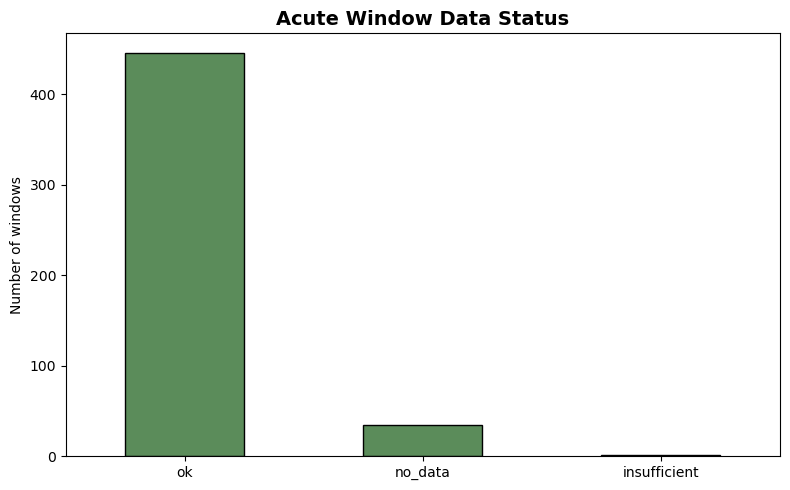

In [82]:
# Plot 1: Data status counts
fig, ax = plt.subplots(figsize=(8, 5))
status_counts = df["data_status"].value_counts()
status_counts.plot(kind="bar", ax=ax, edgecolor="black", color="#5B8C5A")
ax.set_title("Acute Window Data Status", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of windows")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT_DIR / "plot1_data_status_counts.png", dpi=150)
plt.show()

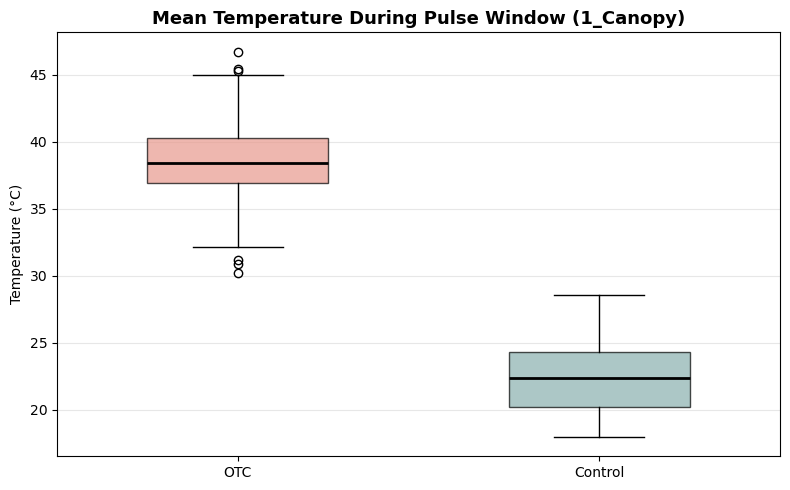

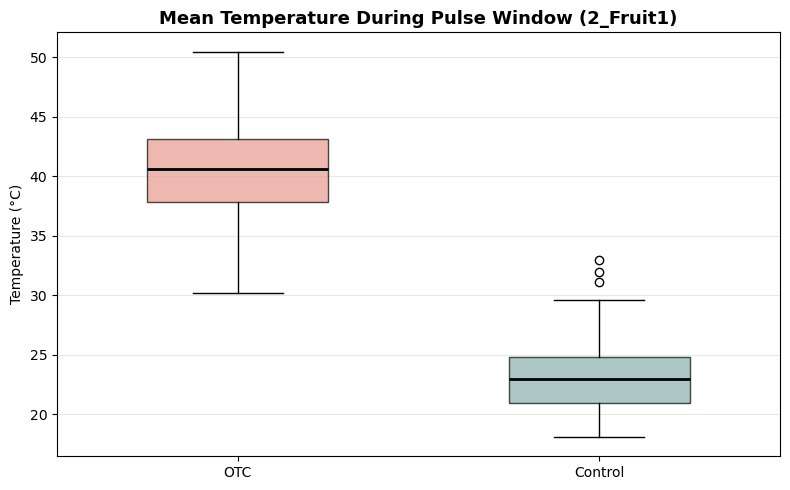

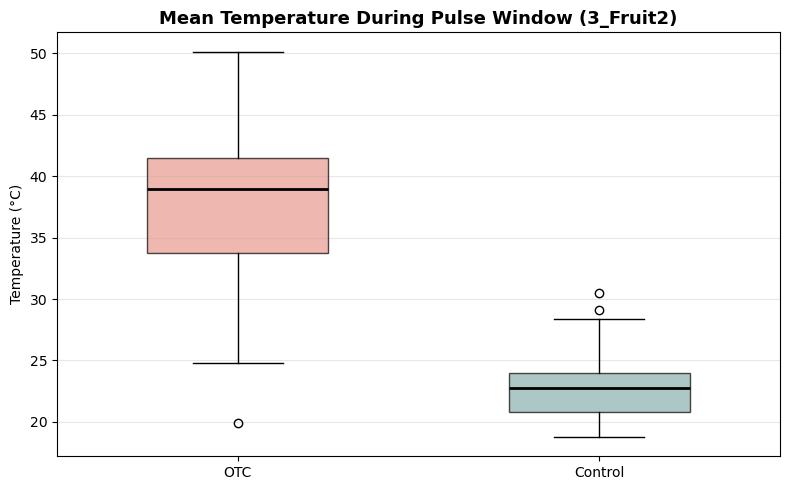

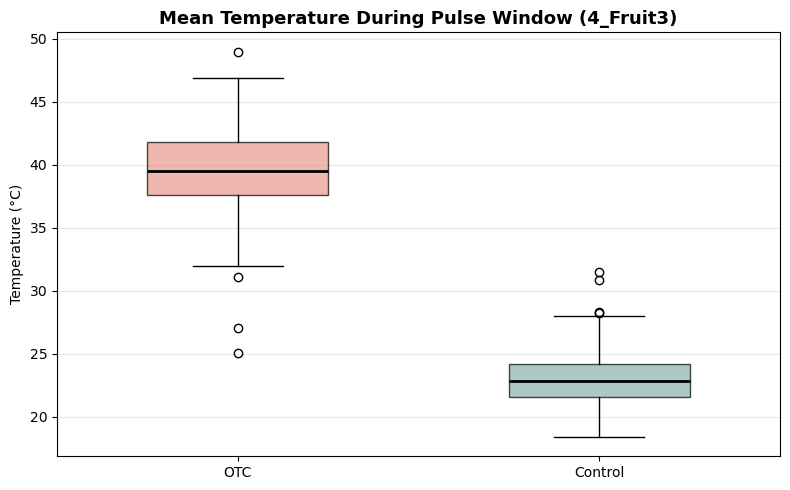

In [83]:
# Plot 2: OTC vs Control boxplot (canopy channel)
for ch in channel_order:
    sub = ok[ok["Channel"] == ch]
    otc_vals = sub.loc[sub["plot_type"] == "OTC", "temp_mean"].dropna()
    ctl_vals = sub.loc[sub["plot_type"] == "Control", "temp_mean"].dropna()
    if len(otc_vals) == 0 and len(ctl_vals) == 0:
        continue

    fig, ax = plt.subplots(figsize=(8, 5))
    bp = ax.boxplot([otc_vals, ctl_vals], labels=["OTC", "Control"],
                    patch_artist=True, widths=0.5,
                    medianprops=dict(color="black", linewidth=2))
    bp["boxes"][0].set_facecolor("#E8998D"); bp["boxes"][0].set_alpha(0.7)
    bp["boxes"][1].set_facecolor("#89B0AE"); bp["boxes"][1].set_alpha(0.7)
    ax.set_title(f"Mean Temperature During Pulse Window ({ch})",
                 fontsize=13, fontweight="bold")
    ax.set_ylabel("Temperature (°C)")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"plot2_temp_mean_otc_vs_control_{ch}.png", dpi=150)
    plt.show()

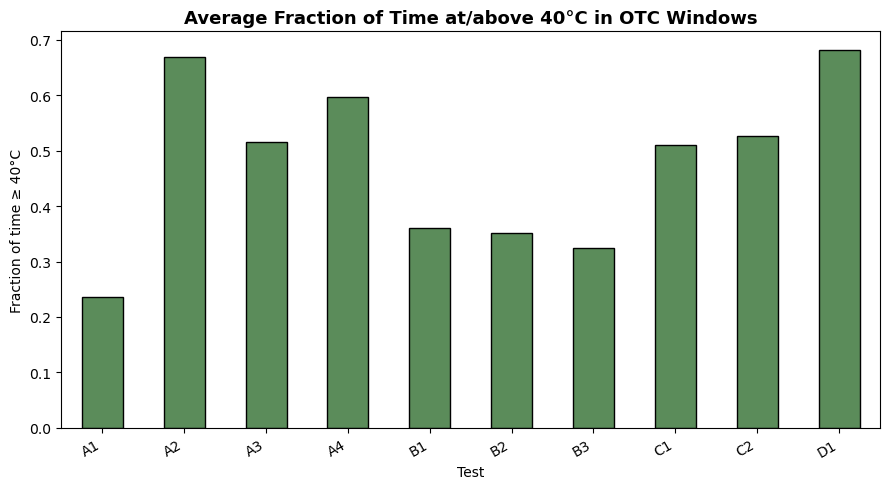

In [84]:
# Plot 3: Fraction of time >= 40 C by test (OTC only)
otc_only = ok[ok["plot_type"] == "OTC"]
otc_pct40 = otc_only.groupby("Test")["pct_ge_40"].mean().reindex(test_order)

fig, ax = plt.subplots(figsize=(9, 5))
otc_pct40.plot(kind="bar", ax=ax, edgecolor="black", color="#5B8C5A")
ax.set_title("Average Fraction of Time at/above 40°C in OTC Windows",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Fraction of time ≥ 40°C")
ax.set_xlabel("Test")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot3_otc_mean_pct_ge_40_by_test.png", dpi=150)
plt.show()

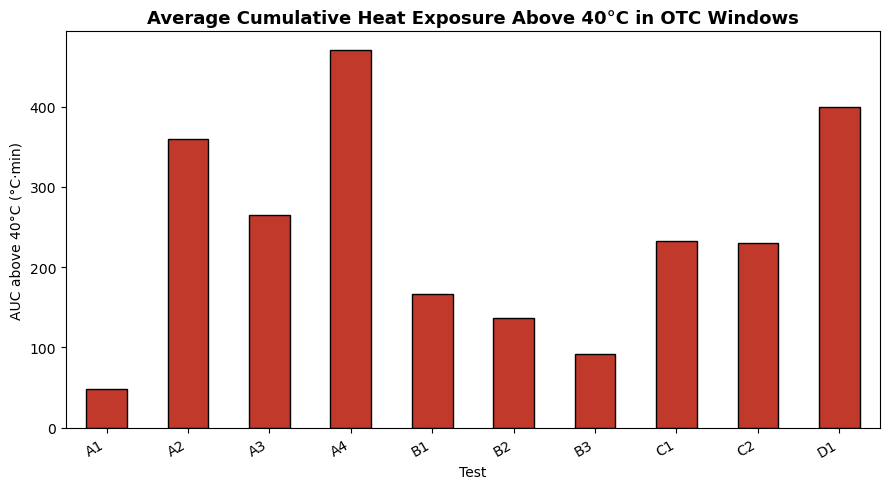

In [85]:
# Plot 4: AUC above 40 C by test (OTC only)
otc_auc = otc_only.groupby("Test")["auc_over_40_degC_min"].mean().reindex(test_order)

fig, ax = plt.subplots(figsize=(9, 5))
otc_auc.plot(kind="bar", ax=ax, edgecolor="black", color="#C0392B")
ax.set_title("Average Cumulative Heat Exposure Above 40°C in OTC Windows",
             fontsize=13, fontweight="bold")
ax.set_ylabel("AUC above 40°C (°C·min)")
ax.set_xlabel("Test")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(OUT_DIR / "plot4_otc_mean_auc40_by_test.png", dpi=150)
plt.show()

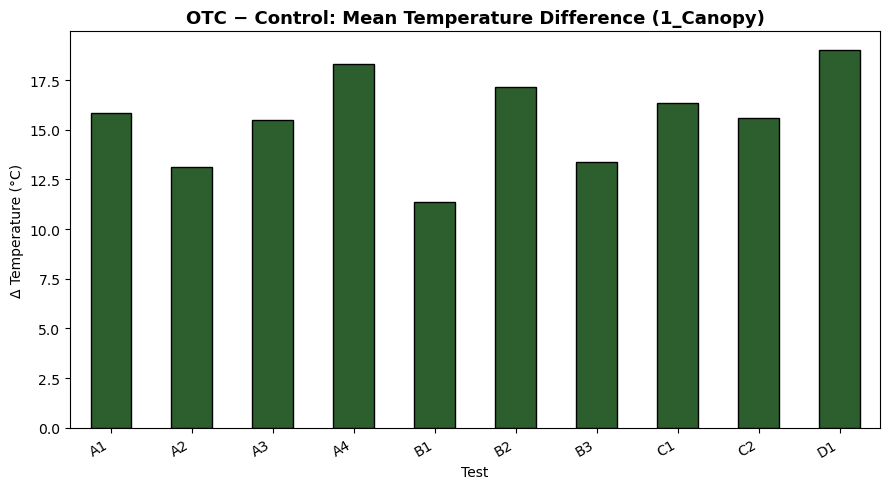

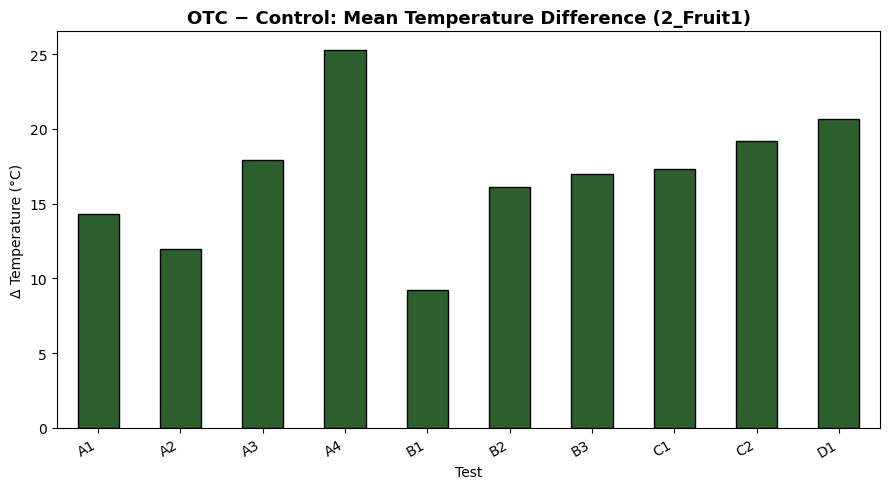

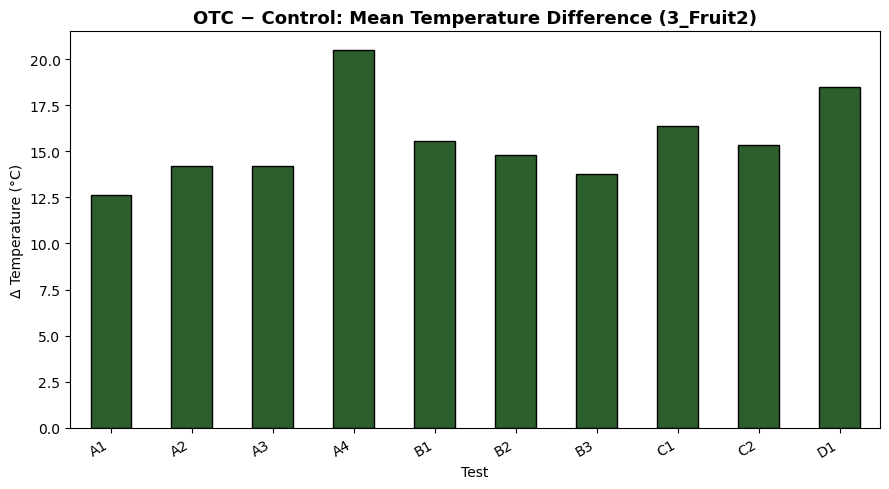

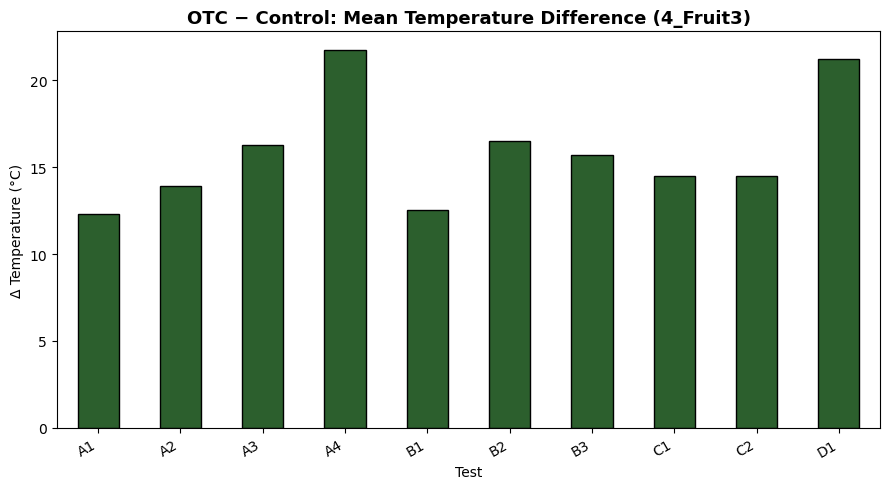

In [86]:
# Plot 5: Delta temp mean by test and channel
if "delta_temp_mean" in pair_wide.columns:
    for ch in channel_order:
        sub = pair_wide[pair_wide["Channel"] == ch]
        series = sub.groupby("Test")["delta_temp_mean"].mean().reindex(test_order)
        if series.dropna().empty:
            continue

        fig, ax = plt.subplots(figsize=(9, 5))
        series.plot(kind="bar", ax=ax, edgecolor="black", color="#2C5F2D")
        ax.set_title(f"OTC − Control: Mean Temperature Difference ({ch})",
                     fontsize=13, fontweight="bold")
        ax.set_ylabel("Δ Temperature (°C)")
        ax.set_xlabel("Test")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.savefig(OUT_DIR / f"plot5_delta_temp_mean_{ch}.png", dpi=150)
        plt.show()

## 18. Summary — All Outputs

All output files are saved to the `acute_temp_outputs/` folder:

**Data files:**
- `acute_4ch_clean_long.csv` — cleaned long-format temperature data
- `acute_4ch_window_kpi.csv` — per-window temperature KPIs

**QC tables:**
- `qc_overall.csv`, `qc_by_test.csv`

**Analysis tables:**
- `performance_by_plot_type_channel.csv`
- `paired_otc_vs_control.csv`, `paired_delta_by_channel.csv`

**Plots:**
- `plot1` — data status counts
- `plot2` — OTC vs Control boxplots by channel
- `plot3` — fraction of time ≥ 40°C by test
- `plot4` — cumulative heat exposure by test
- `plot5` — OTC − Control temperature difference by test and channel